In [1]:
import pandas as pd

sheets = pd.read_excel("indicatorsMY_v02.xlsx", sheet_name=None)

# Vérifie les noms des feuilles
print(sheets.keys())

# Exemple : afficher les premières lignes de la feuille 'Alternatives'
df = sheets['Alternatives']
df.shape

dict_keys(['Alternatives', 'Market_Indicators', 'Price_Level_BTC', 'Open_Interests_Futures', 'Money_Supply', 'Central_Banks_Balance_Sheets', 'Central_Banks_Policy_Rates', 'TED_Spreads', '3M_Gov__Bonds', 'Yield_Curve', 'Foreign_Exchange', 'Miscellaneous', 'Gross_Domestic_Products', 'Industrial_Production', 'Retail_Sales', 'Inflation', 'Economic Policy Uncertainty', 'News Based Policy Uncertainty', 'Economic_Surprises', 'Semiconductor_Market_Dynamics', 'Sentiment', 'OnChain'])


(136, 5869)

In [2]:
import pandas as pd

#ALLOWED_VARS = {"px_open","px_last","px_high","px_low","px_volume"}
DEFAULT_VAR = "px_last"  # variable par défaut pour les séries type Sentiment/OnChain

df_list = []

for name, sheet in sheets.items():
    sheet = sheet.dropna(how="all", axis=0).dropna(how="all", axis=1)
    if sheet.shape[1] < 3:
        continue

    a1 = str(sheet.columns[0]).strip().lower()
    b1 = str(sheet.columns[1]).strip().upper()

    # ======================================================
    # FORMAT PRIX (Alternatives, etc.)
    # A = Ticker | B = Variable | C.. = Dates
    # On garde UNIQUEMENT px_last
    # ======================================================
    if b1 == "DATES":
        tmp = sheet.copy()
        tmp.columns = ["Ticker", "Variable"] + list(tmp.columns[2:])

        tmp["Variable"] = tmp["Variable"].astype(str).str.strip()
        tmp = tmp[tmp["Variable"] == DEFAULT_VAR]   # <<< FILTRE ICI

        if tmp.empty:
            continue

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    # ======================================================
    # FORMAT FEATURES (Sentiment / OnChain / Indices)
    # A = date | ligne suivante = feature
    # Variable forcée à px_last
    # ======================================================
    elif a1 == "date":
        tmp = sheet.copy()

        tmp = tmp.rename(columns={tmp.columns[0]: "Ticker"})
        tmp.insert(1, "Variable", DEFAULT_VAR)

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    else:
        continue

    # ======================================================
    # Nettoyage
    # ======================================================
    melted["Date"] = pd.to_datetime(melted["Date"], errors="coerce")

    melted["Value"] = (
        melted["Value"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )
    melted["Value"] = pd.to_numeric(melted["Value"], errors="coerce")

    melted = melted.dropna(subset=["Date", "Value"])

    melted["Ticker"] = melted["Ticker"].astype(str).str.strip()
    melted["Variable"] = DEFAULT_VAR
    melted["Category"] = name

    df_list.append(melted)

# ======================================================
# CONCATÉNATION FINALE
# ======================================================
merged_df = pd.concat(df_list, ignore_index=True)

print("Variables disponibles :", merged_df["Variable"].unique())
print("Nombre de tickers :", merged_df["Ticker"].nunique())


Variables disponibles : ['px_last']
Nombre de tickers : 200


In [3]:
merged_df[['Category', 'Ticker', 'Variable']].drop_duplicates().head(50)

,Category,Ticker,Variable
0,Alternatives,DXY Curncy,px_last
1,Alternatives,XAU Curncy,px_last
2,Alternatives,SPX Index,px_last
3,Alternatives,CCMP Index,px_last
4,Alternatives,RTY Index,px_last
5,Alternatives,CRY Index,px_last
6,Alternatives,SPGSCITR Index,px_last
7,Alternatives,SXXP Index,px_last
8,Alternatives,SHCOMP Index,px_last
14,Alternatives,LUATTRUU Index,px_last


In [4]:
merged_df["Value"].dtype, merged_df["Value"].head()

(dtype('float64'),
 0      76.12601
 1    1057.03000
 2    1076.19000
 3    2139.14000
 4     613.80500
 Name: Value, dtype: float64)

In [5]:
# Nettoyage global de la colonne Value
merged_df["Value"] = (
    merged_df["Value"]
    .astype(str)         # convertir en string
    .str.replace(",", ".")  # remplacer virgules
    .str.replace(" ", "")   # enlever espaces
    .str.replace("-", "")    # remplacer les tirets
)

# Conversion en float
merged_df["Value"] = pd.to_numeric(merged_df["Value"], errors="coerce")

In [6]:
# Convert all dates to datetime
merged_df["Date"] = pd.to_datetime(merged_df["Date"], errors="coerce")

# Force all dates to be timezone-naive
merged_df["Date"] = merged_df["Date"].dt.tz_localize(None)

In [7]:
pivot_df = merged_df.pivot_table(
    index="Date",
    columns="Ticker",
    values="Value",
    aggfunc='mean'   # corrige les doublons mélangés
)

corr = pivot_df.corr()
corr


Ticker,AdrActCnt,BASPTDSP Index,BDIY Index,BOJDPBAL Index,BlkCnt,CCMP Index,CESICNY Index,CESIEUR Index,CESIJPY Index,CESIUSD Index,...,mempool_growth,mempool_size_bytes,miner_revenue_usd,mining_difficulty,n_tx_excl_popular,price_usd,tx_fees_usd,tx_per_block,tx_per_second,utxo_count
Ticker,,,,,,,,,,,,,,,,,,,,,
AdrActCnt,1.000000,0.064268,0.485537,0.012550,0.060275,0.521500,0.054565,0.410257,0.145737,0.296581,...,0.284283,0.281877,0.571241,0.249534,0.392391,-0.093066,0.233444,0.391351,0.274072,0.357221
BASPTDSP Index,0.064268,1.000000,-0.272594,NaN,-0.021686,0.270147,0.031466,0.165858,-0.210168,0.020924,...,0.073628,-0.301102,-0.117918,-0.100492,0.176128,-0.074607,-0.132178,0.203814,0.104114,0.174945
BDIY Index,0.485537,-0.272594,1.000000,0.036977,-0.064568,0.233174,-0.069309,0.080409,0.179934,-0.050504,...,0.012354,0.069579,0.631556,0.258872,0.222923,-0.038660,0.163902,0.221326,0.132556,0.328236
BOJDPBAL Index,0.012550,NaN,0.036977,1.000000,-0.033794,0.576788,-0.117921,-0.148603,-0.136058,-0.169421,...,0.052043,-0.064148,0.394868,0.763197,0.352002,-0.012156,-0.051594,0.344349,0.165110,0.609678
BlkCnt,0.060275,-0.021686,-0.064568,-0.033794,1.000000,-0.111503,-0.101813,-0.059739,-0.098370,0.000024,...,0.040531,-0.027556,0.008288,-0.083498,-0.004266,-0.011690,0.005440,-0.111446,-0.001478,-0.073917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
price_usd,-0.093066,-0.074607,-0.038660,-0.012156,-0.011690,-0.052698,-0.039370,-0.044269,-0.015391,-0.008558,...,-0.025197,-0.010471,-0.047317,-0.033123,-0.065255,1.000000,-0.014509,-0.070128,-0.031075,-0.056166
tx_fees_usd,0.233444,-0.132178,0.163902,-0.051594,0.005440,0.172853,-0.078823,0.139531,0.095097,0.059944,...,0.133237,0.378540,0.411672,0.125381,0.263347,-0.014509,1.000000,0.273559,0.175180,0.194710
tx_per_block,0.391351,0.203814,0.221326,0.344349,-0.111446,0.675226,-0.101149,0.026842,-0.146226,0.007678,...,0.299220,0.471387,0.498025,0.695349,0.877768,-0.070128,0.273559,1.000000,0.510983,0.788411


In [8]:
# Voir toutes les catégories disponibles
print("Catégories disponibles :")
print(merged_df['Category'].unique())
print("\nNombre total de catégories :", merged_df['Category'].nunique())

# Voir tous les tickers disponibles
print("\nTickers disponibles :")
print(merged_df['Ticker'].unique())
print("\nNombre total de tickers :", merged_df['Ticker'].nunique())

# Voir toutes les variables disponibles (px_open, px_last, etc.)
print("\nVariables disponibles :")
print(merged_df['Variable'].unique())
print("\nNombre total de variables :", merged_df['Variable'].nunique())

Catégories disponibles :
['Alternatives' 'Market_Indicators' 'Price_Level_BTC'
 'Open_Interests_Futures' 'Money_Supply' 'Central_Banks_Balance_Sheets'
 'Central_Banks_Policy_Rates' 'TED_Spreads' '3M_Gov__Bonds' 'Yield_Curve'
 'Foreign_Exchange' 'Miscellaneous' 'Gross_Domestic_Products'
 'Industrial_Production' 'Retail_Sales' 'Inflation'
 'Economic Policy Uncertainty' 'News Based Policy Uncertainty'
 'Economic_Surprises' 'Semiconductor_Market_Dynamics' 'Sentiment'
 'OnChain']

Nombre total de catégories : 22

Tickers disponibles :
['DXY Curncy' 'XAU Curncy' 'SPX Index' 'CCMP Index' 'RTY Index'
 'CRY Index' 'SPGSCITR Index' 'SXXP Index' 'SHCOMP Index' 'LUATTRUU Index'
 'LUACTRUU Index' 'LF98TRUU Index' 'NKY Index' 'XETUSD Curncy'
 'XLCUSD Curncy' 'XBNUSD Curncy' 'XRPUSD Curncy' 'XDGUSD Curncy'
 'XADUSD Curncy' 'XSOUSD Curncy' 'VIX Index' 'MOVE Index' 'CVIX Index'
 'RIOT US Equity' 'JPMVXYGL Index' 'MARA US Equity' 'CIFR US Equity'
 'IREN US Equity' 'CORZ US Equity' 'XBTUSD Curncy' 'CFC5Q

In [9]:
print(merged_df['Ticker'].nunique())

200


## Scénarios de rendement QUANTILES
Afin de transformer les rendements futurs du Bitcoin en une variable cible de classification,
nous adoptons une approche fondée sur des **quantiles calculés exclusivement sur la période
d’entraînement**.

Concrètement, pour chaque horizon de prédiction, les rendements futurs observés sur le jeu
d’entraînement sont découpés en cinq classes de taille égale (quintiles), correspondant aux
scénarios suivants :

- Very Bear : rendements parmi les 20 % les plus faibles  
- Bear  
- Neutral  
- Bull  
- Very Bull : rendements parmi les 20 % les plus élevés  

Les seuils de ces classes sont **estimés uniquement sur les données d’entraînement**, puis
appliqués tels quels au jeu de test. Cette procédure garantit :
- l’absence totale de fuite d’information (data leakage),
- des classes équilibrées sur le jeu d’entraînement,
- une évaluation hors échantillon réaliste.

Cette approche permet d’identifier des **régimes relatifs de performance future** plutôt que
des événements extrêmes absolus, et se révèle particulièrement adaptée aux séries financières
fortement non gaussiennes et asymétriques, comme les rendements des crypto-actifs.

In [10]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"

# Split "logique" par date (train <= TRAIN_END_DATE, test > TRAIN_END_DATE)
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"  # "simple" ou "log"

N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

MIN_NON_NA_FRAC = 0.70   # après ffill
MIN_ROWS = 300

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# TARGET: FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)

    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

# ============================================================
# SCENARIO BINS (TRAIN-ONLY) -> NO LEAKAGE
# ============================================================

def fit_quantile_bins(train_returns: pd.Series, n_bins: int = 5) -> np.ndarray:
    x = train_returns.dropna().values
    if len(x) < 50:
        raise ValueError("Not enough training returns to fit bins")

    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf

    # éviter les bords identiques
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12

    return qs

def apply_bins(returns: pd.Series, bins: np.ndarray) -> pd.Series:
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

# ============================================================
# EVALUATION (CLASSIFICATION ONLY, LEAKAGE SAFE, DATE SPLIT)
# ============================================================

def evaluate_horizon_classification_leakfree_by_date(
    pivot_df: pd.DataFrame,
    horizon: int,
    return_type: str = "simple",
    train_end_date: str = TRAIN_END_DATE,
    start_date: str = START_DATE
):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(start_date)]

    # BTC column detection (robust)
    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("Colonne BTC introuvable (attendu: 'XBTUSD Curncy' ou 'XBTUSD').")

    # ---------- Features: ffill ONLY (NO bfill) ----------
    df_features = df.ffill()

    # drop columns too incomplete after ffill
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    # ---------- Target returns ----------
    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    # build modeling frame
    df_model = df_features.copy()
    df_model["target_return"] = returns

    # remove rows where target not available (future missing)
    df_model = df_model.dropna(subset=["target_return"])
    if len(df_model) < MIN_ROWS:
        return None

    # split by date
    cut = pd.to_datetime(train_end_date)
    train_mask = df_model.index <= cut
    test_mask = df_model.index > cut

    if train_mask.sum() < MIN_ROWS or test_mask.sum() < 50:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # remove return-like columns (safety)
    X_full = X_full.drop(columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()], errors="ignore")

    # remove BTC level EXACTLY (not contains)
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    # split
    X_train = X_full.loc[train_mask].copy()
    X_test  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # train-only bins -> scenarios
    bins = fit_quantile_bins(y_ret_train, n_bins=N_BINS)
    y_train = apply_bins(y_ret_train, bins).dropna().astype(int)
    y_test  = apply_bins(y_ret_test, bins).dropna().astype(int)

    # align X with possible dropped rows
    X_train = X_train.loc[y_train.index]
    X_test  = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    # scaling (fit train only)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # model
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # metrics
    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

    # full importances (not only top10)
    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    # useful stats: train/test returns
    ret_stats_train = {
        "mean": float(y_ret_train.mean()),
        "std": float(y_ret_train.std()),
        "min": float(y_ret_train.min()),
        "max": float(y_ret_train.max()),
        "skew": float(y_ret_train.skew()),
        "kurt": float(y_ret_train.kurtosis()),
    }
    ret_stats_test = {
        "mean": float(y_ret_test.mean()),
        "std": float(y_ret_test.std()),
        "min": float(y_ret_test.min()),
        "max": float(y_ret_test.max()),
        "skew": float(y_ret_test.skew()),
        "kurt": float(y_ret_test.kurtosis()),
    }

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": str(train_end_date),

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,

        "top_features": imp_full.head(10),
        "imp_full": imp_full,

        "ret_stats_train": ret_stats_train,
        "ret_stats_test": ret_stats_test
    }

# ============================================================
# RUN MULTI-HORIZONS + SUMMARY + RECURRENT FEATURES
# ============================================================

print("=" * 95)
print("MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print("=" * 95)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 95)
    print(f"Horizon = {h} days")
    print("=" * 95)

    res = evaluate_horizon_classification_leakfree_by_date(
        pivot_df,
        horizon=h,
        return_type=RETURN_TYPE,
        train_end_date=TRAIN_END_DATE,
        start_date=START_DATE
    )

    if res is None:
        print("-> Not enough data / too few usable features with this date split.")
        continue

    all_results.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Train N={res['n_train']} | Test N={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print("\nTop 10 features:")
    print(res["top_features"][["rank","feature","importance"]].to_string(index=False))

    for _, row in res["imp_full"].head(10).iterrows():
        feature_tracker[row["feature"]].append((h, float(row["importance"])))

# SUMMARY TABLE
if all_results:
    summary_df = pd.DataFrame([{
        "Horizon (d)": r["horizon"],
        "Train N": r["n_train"],
        "Test N": r["n_test"],
        "Acc (%)": r["acc"] * 100,
        "BalAcc (%)": r["bal_acc"] * 100,
        "MacroF1": r["macro_f1"],
        "Train mean ret": r["ret_stats_train"]["mean"],
        "Train std ret": r["ret_stats_train"]["std"],
        "Test mean ret": r["ret_stats_test"]["mean"],
        "Test std ret": r["ret_stats_test"]["std"],
    } for r in all_results]).sort_values("Horizon (d)")

    print("\n" + "=" * 95)
    print("SUMMARY")
    print("=" * 95)
    print(summary_df.to_string(index=False))

    print("\n" + "=" * 95)
    print("MOST RECURRENT FEATURES (top-20 across horizons, from top-10 each horizon)")
    print("=" * 95)

    feat_counts = {feat: len(v) for feat, v in feature_tracker.items()}
    for feat, count in sorted(feat_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
        horizons_str = ", ".join([f"{h}d" for h, _ in feature_tracker[feat]])
        avg_imp = float(np.mean([imp for _, imp in feature_tracker[feat]]))
        print(f"{feat:35s} -> {count}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")

else:
    print("No results (all horizons failed).")

# ============================================================
# OPTIONAL: CHECK IMPORTANCE FOR SPECIFIC FEATURES (e.g., RIOT, DXY)
# After running, you can do:
#
#   r = all_results[0]
#   r["imp_full"][r["imp_full"]["feature"].str.contains("RIOT|DXY", case=False, na=False)][["rank","feature","importance"]]
#
# ============================================================


MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)
Train <= 2023-12-31 | Test > 2023-12-31

Horizon = 1 days
BTC col used: XBTUSD Curncy
Train N=1938 | Test N=673
Acc=21.8% | BalAcc=20.4% | MacroF1=0.123

Top 10 features:
 rank           feature  importance
    1   hashrate_7d_pct    0.018845
    2 active_addr_ratio    0.017626
    3               NVT    0.017098
    4            BlkCnt    0.016392
    5     XBNUSD Curncy    0.015834
    6          TxTfrCnt    0.015773
    7         AdrActCnt    0.015012
    8     tx_per_second    0.014945
    9             TxCnt    0.014770
   10     XLCUSD Curncy    0.014220

Horizon = 14 days
BTC col used: XBTUSD Curncy
Train N=2035 | Test N=660
Acc=24.5% | BalAcc=20.0% | MacroF1=0.112

Top 10 features:
 rank              feature  importance
    1        XBNUSD Curncy    0.022674
    2        XLCUSD Curncy    0.018522
    3           CapMVRVCur    0.016433
    4   days_since_halving    0.015543
    5 days_to_next_halving    0.01540

Avec 21.8% de précision (vs 20.4% aléatoire), le modèle ne capture statistiquement que du bruit blanc sur l'horizon 1 jour. 


Il y a une inadéquation fréquentielle majeure : les métriques on-chain (lentes) ne peuvent pas expliquer la volatilité quotidienne (rapide). 
(Des variables de tendance structurelle (basse fréquence) sont mathématiquement incapables de prédire le bruit de marché quotidien (haute fréquence).

)
Il faut arreter le court terme et se concentrer sur les horizons 14 jours et plus, où l'inertie des fondamentaux devient prédictive.

In [11]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"

# Split logique par date (pas juste 80/20 arbitraire)
# Exemple : train <= 2023-12-31, test > 2023-12-31
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"  # "simple" ou "log"

N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

# Drop colonnes trop incomplètes après ffill (réglable)
MIN_NON_NA_FRAC = 0.70

MIN_ROWS_TOTAL = 300     # dataset minimal après target
MIN_ROWS_TRAIN = 300     # train minimal
MIN_ROWS_TEST = 50       # test minimal

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# TARGET: FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)

    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

# ============================================================
# SCENARIO BINS (TRAIN-ONLY) -> NO LEAKAGE
# ============================================================

def fit_quantile_bins(train_returns: pd.Series, n_bins: int = 5) -> np.ndarray:
    x = train_returns.dropna().values
    if len(x) < 50:
        raise ValueError("Not enough training returns to fit bins")

    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf

    # avoid duplicate edges
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12

    return qs

def apply_bins(returns: pd.Series, bins: np.ndarray) -> pd.Series:
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

# ============================================================
# EVALUATION (CLASSIFICATION ONLY, LEAKAGE SAFE, DATE SPLIT)
# ============================================================

def evaluate_horizon_classification_leakfree(pivot_df: pd.DataFrame, horizon: int, return_type: str = "simple"):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]

    # BTC column detection (robust)
    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("Colonne BTC introuvable (attendu: 'XBTUSD Curncy' ou 'XBTUSD').")

    # -------- Features leakage-safe: ffill ONLY (NO bfill) --------
    df_features = df.ffill()

    # Drop columns too incomplete after ffill
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    # -------- Target returns --------
    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    # Build modeling frame
    df_model = df_features.copy()
    df_model["target_return"] = returns

    # remove rows where target is missing (future not available)
    df_model = df_model.dropna(subset=["target_return"])

    if len(df_model) < MIN_ROWS_TOTAL:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # Remove any return-like columns (safety)
    X_full = X_full.drop(
        columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()],
        errors="ignore"
    )

    # Remove BTC level EXACTLY (évite de dropper des colonnes qui contiennent "XBTUSD" par accident)
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    # -------- Split logique par DATE --------
    cut = pd.to_datetime(TRAIN_END_DATE)
    train_mask = X_full.index <= cut
    test_mask = X_full.index > cut

    if train_mask.sum() < MIN_ROWS_TRAIN or test_mask.sum() < MIN_ROWS_TEST:
        return None

    X_train = X_full.loc[train_mask].copy()
    X_test  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # -------- Train-only bins -> scenario labels (NO LEAKAGE) --------
    bins = fit_quantile_bins(y_ret_train, n_bins=N_BINS)
    y_train = apply_bins(y_ret_train, bins).dropna().astype(int)
    y_test  = apply_bins(y_ret_test, bins).dropna().astype(int)

    # align X with any dropped rows
    X_train = X_train.loc[y_train.index]
    X_test  = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    # -------- Scaling (fit train only) --------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # -------- Model --------
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # -------- Metrics --------
    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

    # -------- Dummy baseline (most frequent) --------
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train_scaled, y_train)
    y_dummy = dummy.predict(X_test_scaled)

    dummy_acc = float(accuracy_score(y_test, y_dummy))
    dummy_bal_acc = float(balanced_accuracy_score(y_test, y_dummy))
    dummy_macro_f1 = float(f1_score(y_test, y_dummy, average="macro"))

    # -------- Feature importance (FULL + ranks) --------
    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    # distributions
    dist_train = y_train.value_counts().sort_index()
    dist_test = y_test.value_counts().sort_index()

    # return stats
    ret_stats_train = {
        "mean": float(y_ret_train.mean()),
        "std": float(y_ret_train.std()),
        "min": float(y_ret_train.min()),
        "max": float(y_ret_train.max()),
        "skew": float(y_ret_train.skew()),
        "kurt": float(y_ret_train.kurtosis()),
    }
    ret_stats_test = {
        "mean": float(y_ret_test.mean()),
        "std": float(y_ret_test.std()),
        "min": float(y_ret_test.min()),
        "max": float(y_ret_test.max()),
        "skew": float(y_ret_test.skew()),
        "kurt": float(y_ret_test.kurtosis()),
    }

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": TRAIN_END_DATE,

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,

        "dummy_acc": dummy_acc,
        "dummy_bal_acc": dummy_bal_acc,
        "dummy_macro_f1": dummy_macro_f1,

        "top_features": imp_full.head(10),
        "imp_full": imp_full,  # <-- IMPORTANT: full importance available

        "dist_train": dist_train,
        "dist_test": dist_test,

        "ret_stats_train": ret_stats_train,
        "ret_stats_test": ret_stats_test,
    }

# ============================================================
# RUN MULTI-HORIZONS
# ============================================================

print("=" * 95)
print("MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print("=" * 95)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 95)
    print(f"Horizon = {h} days")
    print("=" * 95)

    res = evaluate_horizon_classification_leakfree(pivot_df, h, return_type=RETURN_TYPE)
    if res is None:
        print("-> Not enough data / too few usable features (with this date split).")
        continue

    all_results.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Train={res['n_train']} | Test={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print(f"Dummy Acc={res['dummy_acc']*100:.1f}% | Dummy BalAcc={res['dummy_bal_acc']*100:.1f}% | Dummy MacroF1={res['dummy_macro_f1']:.3f}")

    print("\nScenario distribution (TEST):")
    total = res["dist_test"].sum()
    for i in range(N_BINS):
        c = int(res["dist_test"].get(i, 0))
        name = SCENARIO_NAMES[i]
        print(f"  {i} {name:10s}: {c:4d} ({(c/total*100 if total else 0):5.1f}%)")

    print("\nTop 10 features:")
    print(res["top_features"][["rank", "feature", "importance"]].to_string(index=False))

    # track recurrent top features
    for _, row in res["top_features"].iterrows():
        feature_tracker[row["feature"]].append((h, float(row["importance"])))

# ============================================================
# SUMMARY TABLE
# ============================================================

if all_results:
    summary_df = pd.DataFrame([{
        "Horizon (d)": r["horizon"],
        "Train N": r["n_train"],
        "Test N": r["n_test"],
        "Acc (%)": r["acc"] * 100,
        "BalAcc (%)": r["bal_acc"] * 100,
        "MacroF1": r["macro_f1"],
        "Dummy Acc (%)": r["dummy_acc"] * 100,
        "Dummy BalAcc (%)": r["dummy_bal_acc"] * 100,
        "Dummy MacroF1": r["dummy_macro_f1"],
        "Train mean ret": r["ret_stats_train"]["mean"],
        "Train std ret": r["ret_stats_train"]["std"],
        "Test mean ret": r["ret_stats_test"]["mean"],
        "Test std ret": r["ret_stats_test"]["std"],
    } for r in all_results]).sort_values("Horizon (d)")

    print("\n" + "=" * 95)
    print("SUMMARY")
    print("=" * 95)
    print(summary_df.to_string(index=False))

    print("\n" + "=" * 95)
    print("MOST RECURRENT FEATURES (top-10 across horizons)")
    print("=" * 95)

    feat_counts = {feat: len(v) for feat, v in feature_tracker.items()}
    for feat, count in sorted(feat_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
        horizons_str = ", ".join([f"{h}d" for h, _ in feature_tracker[feat]])
        avg_imp = float(np.mean([imp for _, imp in feature_tracker[feat]]))
        print(f"{feat:35s} -> {count}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")

    # ============================================================
    # OPTIONAL QUICK CHECK: RIOT / DXY ranks per horizon
    # ============================================================
    print("\n" + "=" * 95)
    print("CHECK: RIOT / DXY ranks (per horizon)")
    print("=" * 95)
    for r in all_results:
        hit = r["imp_full"][r["imp_full"]["feature"].str.contains("RIOT|DXY", case=False, na=False)]
        print(f"\nHorizon {r['horizon']}d:")
        if hit.empty:
            print("  -> RIOT/DXY not found in features (maybe not in pivot_df columns).")
        else:
            print(hit[["rank", "feature", "importance"]].to_string(index=False))

else:
    print("No results (all horizons failed).")


MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)
Train <= 2023-12-31 | Test > 2023-12-31

Horizon = 1 days
BTC col used: XBTUSD Curncy
Train=1938 | Test=673
Acc=21.8% | BalAcc=20.4% | MacroF1=0.123
Dummy Acc=17.1% | Dummy BalAcc=20.0% | Dummy MacroF1=0.058

Scenario distribution (TEST):
  0 Very Bear :  115 ( 17.1%)
  1 Bear      :  143 ( 21.2%)
  2 Neutral   :  146 ( 21.7%)
  3 Bull      :  153 ( 22.7%)
  4 Very Bull :  116 ( 17.2%)

Top 10 features:
 rank           feature  importance
    1   hashrate_7d_pct    0.018845
    2 active_addr_ratio    0.017626
    3               NVT    0.017098
    4            BlkCnt    0.016392
    5     XBNUSD Curncy    0.015834
    6          TxTfrCnt    0.015773
    7         AdrActCnt    0.015012
    8     tx_per_second    0.014945
    9             TxCnt    0.014770
   10     XLCUSD Curncy    0.014220

Horizon = 14 days
BTC col used: XBTUSD Curncy
Train=2035 | Test=660
Acc=24.5% | BalAcc=20.0% | MacroF1=0.112
Dummy Acc=10.0% | 

Avec une Balanced Accuracy de 20.4% sur 1 jour (quasi identique au hasard de 20%), le modèle prouve que les métriques On-Chain (Hashrate, NVT) ne peuvent pas prédire la volatilité quotidienne.

Le fait que le top des features soit occupé par des fondamentaux "lents" alors que la cible est "rapide" explique mécaniquement cette performance nulle (météo vs climat).

L'apparition de RIOT (36e) et DXY (49e) sur l'horizon 60 jours est le début d'une piste valide, mais leur classement lointain indique qu'il manque encore les catalyseurs macro majeurs (comme le Yield Spread) pour capturer pleinement la tendance.

 GENERATION DES VISUALISATIONS (NEW PIPELINE)

 TOUTES LES VISUALISATIONS ONT ETE GENEREES


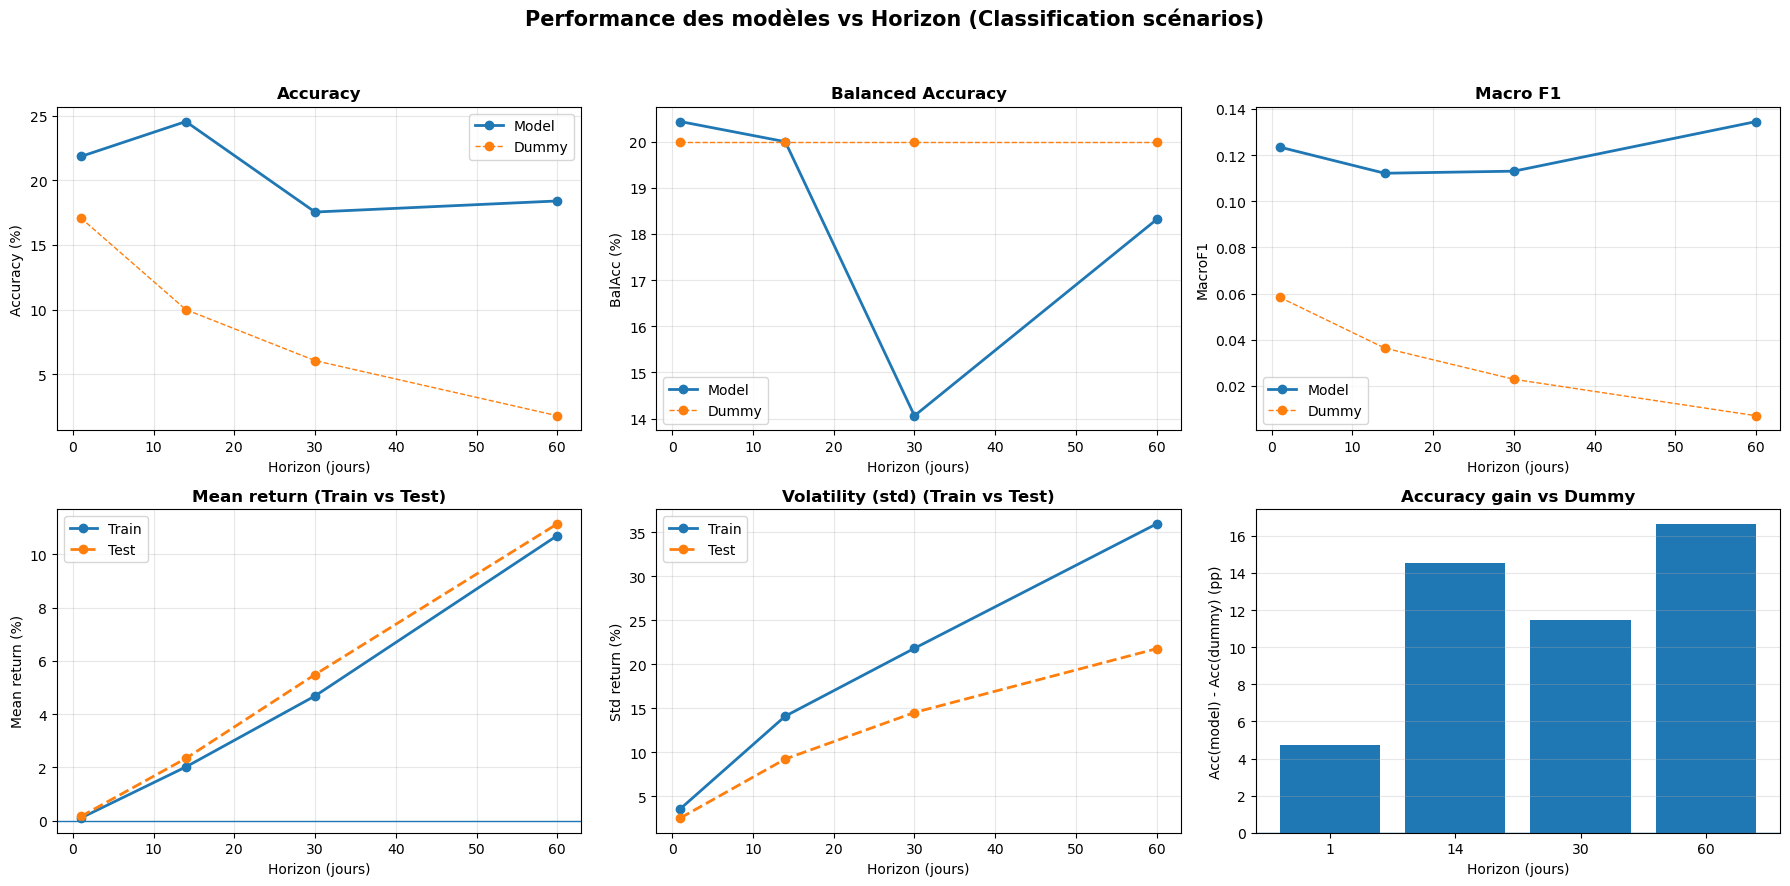

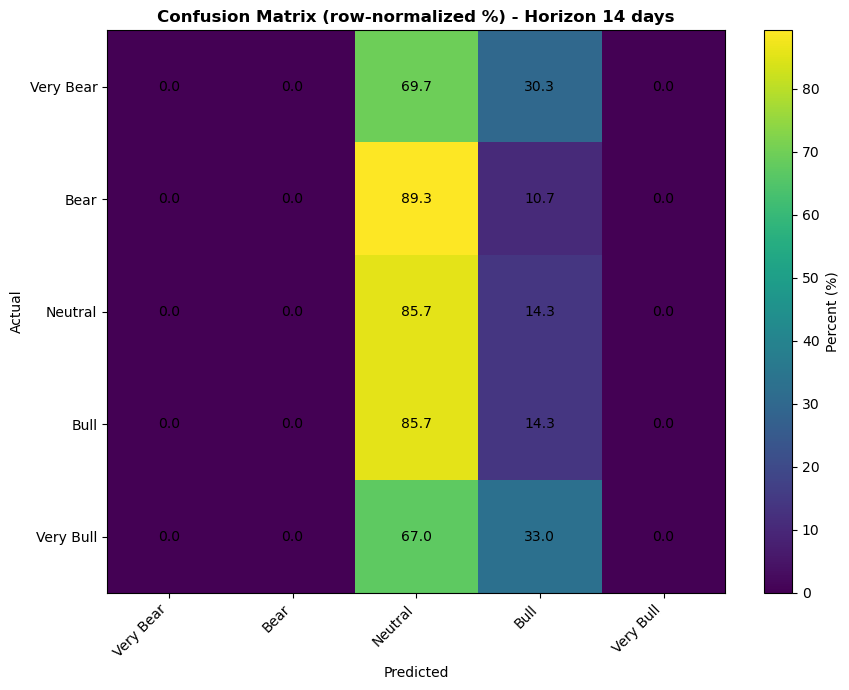

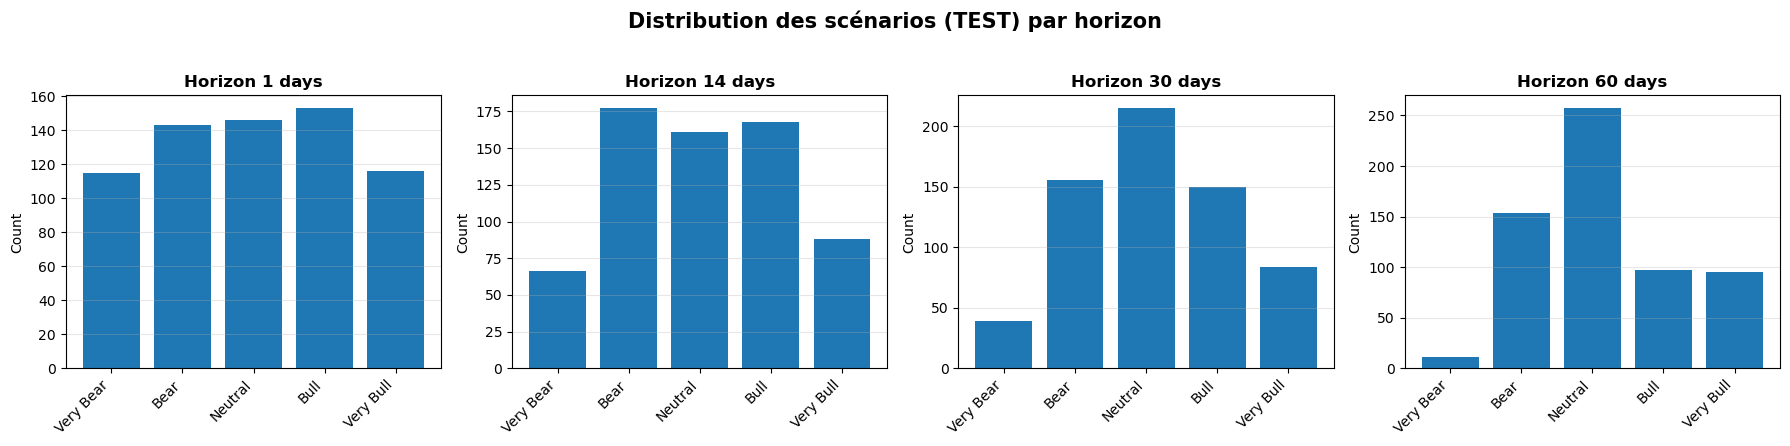

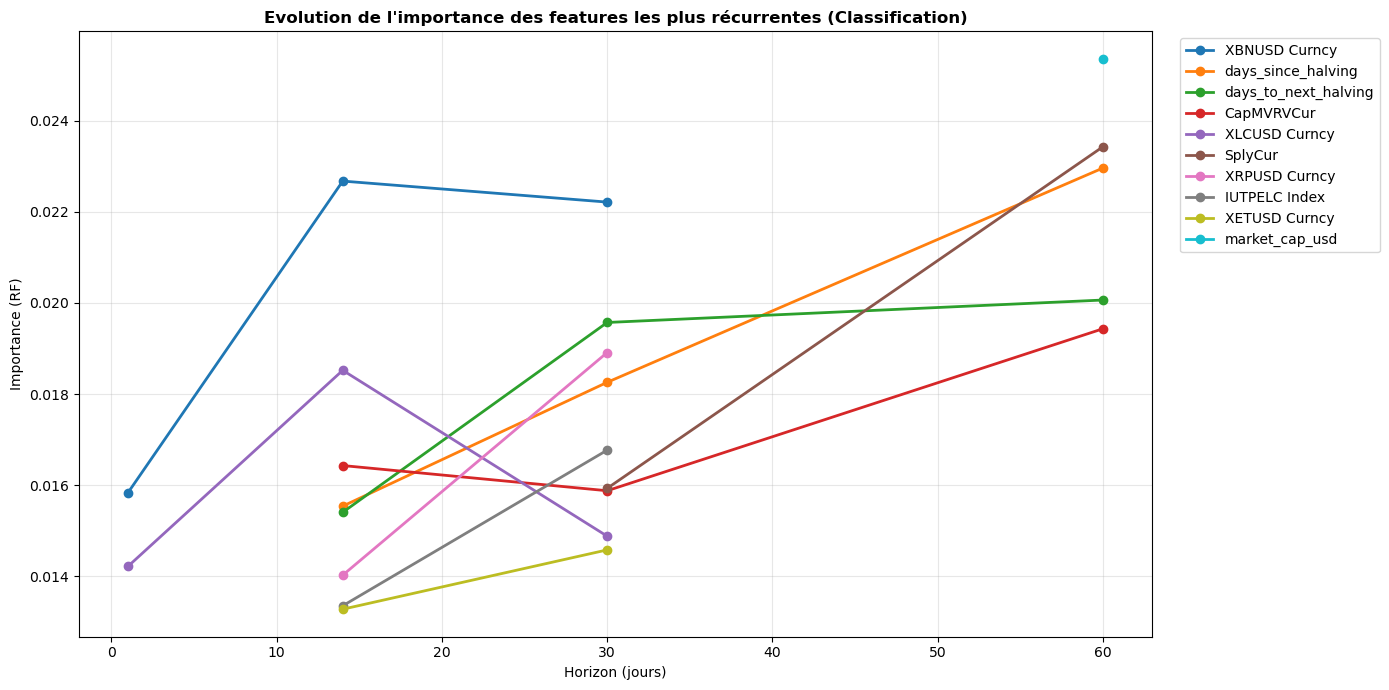

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# VISUALISATIONS (COMPATIBLES AVEC TON NOUVEAU CODE leak-free)
# - all_results : liste de dicts renvoyés par evaluate_horizon_classification_leakfree()
# - feature_tracker : defaultdict(list) rempli dans la boucle (feature -> [(horizon, imp), ...])
# ============================================================

print("="*80)
print(" GENERATION DES VISUALISATIONS (NEW PIPELINE)")
print("="*80)

# Sécurité
if "all_results" not in globals() or len(all_results) == 0:
    raise ValueError("all_results est vide ou non défini. Lance d'abord l'exécution multi-horizons.")
if "feature_tracker" not in globals():
    feature_tracker = None  # certaines figures seront désactivées

# Tri par horizon
all_results_sorted = sorted(all_results, key=lambda r: r["horizon"])

horizons = [r["horizon"] for r in all_results_sorted]
acc = [r["acc"] * 100 for r in all_results_sorted]
bal_acc = [r["bal_acc"] * 100 for r in all_results_sorted]
macro_f1 = [r["macro_f1"] for r in all_results_sorted]
dummy_acc = [r["dummy_acc"] * 100 for r in all_results_sorted]
dummy_bal_acc = [r["dummy_bal_acc"] * 100 for r in all_results_sorted]
dummy_macro_f1 = [r["dummy_macro_f1"] for r in all_results_sorted]

# Returns stats (train/test séparées)
train_mean = [r["ret_stats_train"]["mean"] * 100 for r in all_results_sorted]
train_std = [r["ret_stats_train"]["std"] * 100 for r in all_results_sorted]
test_mean = [r["ret_stats_test"]["mean"] * 100 for r in all_results_sorted]
test_std = [r["ret_stats_test"]["std"] * 100 for r in all_results_sorted]

# ============================================================
# FIGURE 1 : PERFORMANCE VS HORIZON (CLASSIFICATION ONLY)
# ============================================================

fig1, axes = plt.subplots(2, 3, figsize=(18, 9))
fig1.suptitle("Performance des modèles vs Horizon (Classification scénarios)", fontsize=15, fontweight="bold")

# 1) Accuracy
axes[0, 0].plot(horizons, acc, marker="o", linewidth=2)
axes[0, 0].plot(horizons, dummy_acc, marker="o", linewidth=1, linestyle="--")
axes[0, 0].set_title("Accuracy", fontweight="bold")
axes[0, 0].set_xlabel("Horizon (jours)")
axes[0, 0].set_ylabel("Accuracy (%)")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend(["Model", "Dummy"], loc="best")

# 2) Balanced Accuracy
axes[0, 1].plot(horizons, bal_acc, marker="o", linewidth=2)
axes[0, 1].plot(horizons, dummy_bal_acc, marker="o", linewidth=1, linestyle="--")
axes[0, 1].set_title("Balanced Accuracy", fontweight="bold")
axes[0, 1].set_xlabel("Horizon (jours)")
axes[0, 1].set_ylabel("BalAcc (%)")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend(["Model", "Dummy"], loc="best")

# 3) Macro F1
axes[0, 2].plot(horizons, macro_f1, marker="o", linewidth=2)
axes[0, 2].plot(horizons, dummy_macro_f1, marker="o", linewidth=1, linestyle="--")
axes[0, 2].set_title("Macro F1", fontweight="bold")
axes[0, 2].set_xlabel("Horizon (jours)")
axes[0, 2].set_ylabel("MacroF1")
axes[0, 2].grid(alpha=0.3)
axes[0, 2].legend(["Model", "Dummy"], loc="best")

# 4) Mean return train vs test
axes[1, 0].plot(horizons, train_mean, marker="o", linewidth=2)
axes[1, 0].plot(horizons, test_mean, marker="o", linewidth=2, linestyle="--")
axes[1, 0].axhline(0, linewidth=1)
axes[1, 0].set_title("Mean return (Train vs Test)", fontweight="bold")
axes[1, 0].set_xlabel("Horizon (jours)")
axes[1, 0].set_ylabel("Mean return (%)")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(["Train", "Test"], loc="best")

# 5) Std return train vs test
axes[1, 1].plot(horizons, train_std, marker="o", linewidth=2)
axes[1, 1].plot(horizons, test_std, marker="o", linewidth=2, linestyle="--")
axes[1, 1].set_title("Volatility (std) (Train vs Test)", fontweight="bold")
axes[1, 1].set_xlabel("Horizon (jours)")
axes[1, 1].set_ylabel("Std return (%)")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(["Train", "Test"], loc="best")

# 6) Gap model - dummy
gap = [a - d for a, d in zip(acc, dummy_acc)]
axes[1, 2].bar([str(h) for h in horizons], gap)
axes[1, 2].axhline(0, linewidth=1)
axes[1, 2].set_title("Accuracy gain vs Dummy", fontweight="bold")
axes[1, 2].set_xlabel("Horizon (jours)")
axes[1, 2].set_ylabel("Acc(model) - Acc(dummy) (pp)")
axes[1, 2].grid(alpha=0.3, axis="y")

plt.tight_layout(rect=[0, 0, 1, 0.95])

# ============================================================
# HELPER : Confusion matrix plot (matplotlib, normalisée)
# ============================================================

def plot_confusion_matrix_percent(cm, title, class_names):
    cm = np.asarray(cm)
    # normalisation par ligne
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_pct = cm / row_sums * 100.0

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm_pct, aspect="auto")

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    # annotations
    for i in range(cm_pct.shape[0]):
        for j in range(cm_pct.shape[1]):
            ax.text(j, i, f"{cm_pct[i, j]:.1f}", ha="center", va="center")

    fig.colorbar(im, ax=ax, label="Percent (%)")
    ax.grid(False)
    plt.tight_layout()
    return fig, ax

# ============================================================
# FIGURE 2 : MATRICE DE CONFUSION (choix horizon)
# - Ton nouveau code n'a PAS 7 jours dans HORIZONS, donc on prend 14 par défaut si dispo,
#   sinon le premier horizon.
# ============================================================

scenario_names = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

preferred_h = 14 if any(r["horizon"] == 14 for r in all_results_sorted) else all_results_sorted[0]["horizon"]
res_h = next(r for r in all_results_sorted if r["horizon"] == preferred_h)

plot_confusion_matrix_percent(
    res_h["cm"],
    title=f"Confusion Matrix (row-normalized %) - Horizon {preferred_h} days",
    class_names=scenario_names
)

# ============================================================
# FIGURE 3 : DISTRIBUTION DES SCENARIOS (TEST) PAR HORIZON
# ============================================================

n = len(all_results_sorted)
cols = 4
rows = int(np.ceil(n / cols))
fig3, axes = plt.subplots(rows, cols, figsize=(18, 4.5 * rows))
fig3.suptitle("Distribution des scénarios (TEST) par horizon", fontsize=15, fontweight="bold")

axes = np.array(axes).reshape(-1)

for i, res in enumerate(all_results_sorted):
    ax = axes[i]
    dist = res["dist_test"]
    full_dist = pd.Series([0]*5, index=range(5), dtype=float)
    for k, v in dist.items():
        full_dist[int(k)] = float(v)

    ax.bar(range(5), full_dist.values)
    ax.set_title(f"Horizon {res['horizon']} days", fontweight="bold")
    ax.set_xticks(range(5))
    ax.set_xticklabels(scenario_names, rotation=45, ha="right")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3, axis="y")

# hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])

# ============================================================
# FIGURE 4 : EVOLUTION DES TOP FEATURES (classification)
# - basé sur feature_tracker (top récurrentes)
# ============================================================

if feature_tracker is not None and len(feature_tracker) > 0:
    # score de récurrence + importance moyenne
    feat_summary = []
    for feat, vals in feature_tracker.items():
        hs = [h for h, _ in vals]
        imps = [imp for _, imp in vals]
        feat_summary.append({
            "feature": feat,
            "count": len(set(hs)),
            "avg_imp": float(np.mean(imps))
        })
    feat_summary = pd.DataFrame(feat_summary).sort_values(["count", "avg_imp"], ascending=[False, False])

    top_feats = feat_summary.head(10)["feature"].tolist()

    fig4, ax = plt.subplots(figsize=(14, 7))
    for feat in top_feats:
        vals = sorted(feature_tracker[feat], key=lambda x: x[0])
        hs = [h for h, _ in vals]
        imps = [imp for _, imp in vals]
        ax.plot(hs, imps, marker="o", linewidth=2, label=feat)

    ax.set_title("Evolution de l'importance des features les plus récurrentes (Classification)", fontweight="bold")
    ax.set_xlabel("Horizon (jours)")
    ax.set_ylabel("Importance (RF)")
    ax.grid(alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
else:
    print("feature_tracker non disponible -> Figure 4 ignorée.")

print("\n" + "="*80)
print(" TOUTES LES VISUALISATIONS ONT ETE GENEREES")
print("="*80)


Du premier plot : Performance des modèles vs horizon (Classification des scénarios)


1. L'Illusion de la Performance (Graphes 1 & 6) Au premier regard, les résultats semblent génial. Le Graphe 6 affiche un gain de performance massif (+17 points) par rapport au benchmark sur l'horizon 60 jours. Cependant, le Graphe 1 révèle que cette avance n'est pas due à l'excellence du modèle, mais à l'effondrement de la stratégie naïve (Dummy), qui chute à 2% de réussite. Le modèle ne devient pas soudainement bon, c'est simplement que parier aveuglément sur la répétition du passé est devenu une stratégie catastrophique dans ce nouveau régime de marché. (Le modèle ne brille que par contraste : il profite de la défaillance d'un benchmark incapable de s'adapter aux nouvelles conditions de marché.)


2. Le Verdict Réel : (Graphe 2) La véritable mesure de la qualité du modèle se lit sur le Graphe 2 (Balanced Accuracy). La courbe oscille entre 14% et 18%, restant systématiquement en dessous du seuil du hasard (20% pour 5 classes). Le creux à 14% sur l'horizon 30 jours indique que le modèle est anti-prédictif : il prend activement les mauvaises décisions, "biaisé" par son apprentissage passé.


3. Rupture de Stationnarité (Graphes 4 & 5) L'explication de cet échec se trouve dans la comparaison des données d'entraînement et de test. Si les rendements moyens restent cohérents (Graphe 4), la volatilité (Graphe 5) subit une rupture majeure. Le modèle a appris dans un marché violent (Train sigma≈35%) et opère désormais dans un marché calme (Test sigma≈22%). Calibré pour la tempête, il sur-interprète probablement les variations mineures du marché actuel comme des signaux extrêmes, ce qui détruit sa précision.


Plot 2 : Confusion matrix 14 days


1. Le constat : Le modèle s'est "endormi" On observe un biais massif : le modèle prédit "Neutral" la quasi-totalité du temps (entre 70% et 90%). Pire, il ne détecte plus du tout les extrêmes (0% de prédictions Very Bear ou Very Bull). En gros, il ne prend plus de risque et choisit systématiquement la réponse par défaut.


2. La cause technique : Un problème de calibrage L'explication vient de la différence de volatilité. Le modèle a appris ses "seuils" d'alerte pendant une période de marché très violent. Comme le marché actuel est plus calme, les mouvements de prix ne sont plus assez forts pour déclencher ses signaux. Il interprète donc tout comme du calme plat.


3. La conclusion : Modèle dangereux En l'état, on ne peut pas utiliser ce modèle. Son défaut majeur est qu'il est aveugle à la baisse (jamais de prédiction Bear). Si le marché s'effondre, le modèle ne nous préviendra pas, ce qui garantit des pertes financières importantes sans couverture.


Plot 3 : Distribution des scénarios Test par horizon (Analyse de la Distribution (Vérité Terrain))


1. Disparition des Extrêmes : On observe un changement radical de la structure des données. À l'horizon 1 jour, les classes sont équilibrées. À 60 jours, la classe "Very Bear" disparait quasiment (chute de 115 à 10 occurrences). Les seuils de krach définis à l'entraînement ne sont plus jamais atteints dans le test.


2. Concentration sur le "Ventre Mou" Mécaniquement, la distribution s'écrase sur la classe "Neutral", qui devient ultra-dominante à 60 jours (255 observations). Le marché est devenu trop calme par rapport aux critères initiaux du modèle.


3. Conclusion Ce déséquilibre total explique l'échec du benchmark (Dummy) : il continue de parier sur une répartition variée qui n'existe plus. Le modèle, lui, s'adapte en ne prédisant plus que du "Neutre", devenant statistiquement juste mais opérationnellement inutile.


Plot 4 : Analyse de l'Évolution des Features


1. Court Terme (1-14 jours) : Trading de Corrélation Les prix des Altcoins (XBNUSD, XLCUSD) dominent totalement l'importance. Le modèle ne capture pas la valeur intrinsèque du Bitcoin, il se contente de suivre le mouvement de foule du marché crypto (Beta).


2. Long Terme (60 jours) : Retour aux Fondamentaux Changement radical : les Altcoins disparaissent du classement. La market_cap_usd (1ère), le Halving et la Supply Curve prennent le pouvoir. Le modèle délaisse le bruit des voisins pour se focaliser sur la rareté et les cycles économiques structurels du BTC.


3. Conclusion On observe une rotation sectorielle saine : le modèle passe mécaniquement d'un rôle de "suiveur de tendance" (court terme) à un rôle d'analyste fondamental (long terme).




Conclusion Générale :


1. Le modèle est inutilisable. Piégé par une baisse de volatilité entre l'entraînement et le test, il ne détecte plus les mouvements et se réfugie dans la prédiction Neutre. Il est aveugle aux risques de baisse.


2. Le Positif (Logique validée) Le cerveau du modèle fonctionne. Il opère correctement la transition entre le bruit court-terme (prix des Altcoins) et les fondamentaux long-terme (Halving, Rareté). Il regarde les bonnes données.


3. La Solution Le problème est l'échelle, pas le modèle. Il faut abandonner les objectifs fixes pour des seuils dynamiques (ajustés à la volatilité) afin de réactiver sa sensibilité aux mouvements de marché.

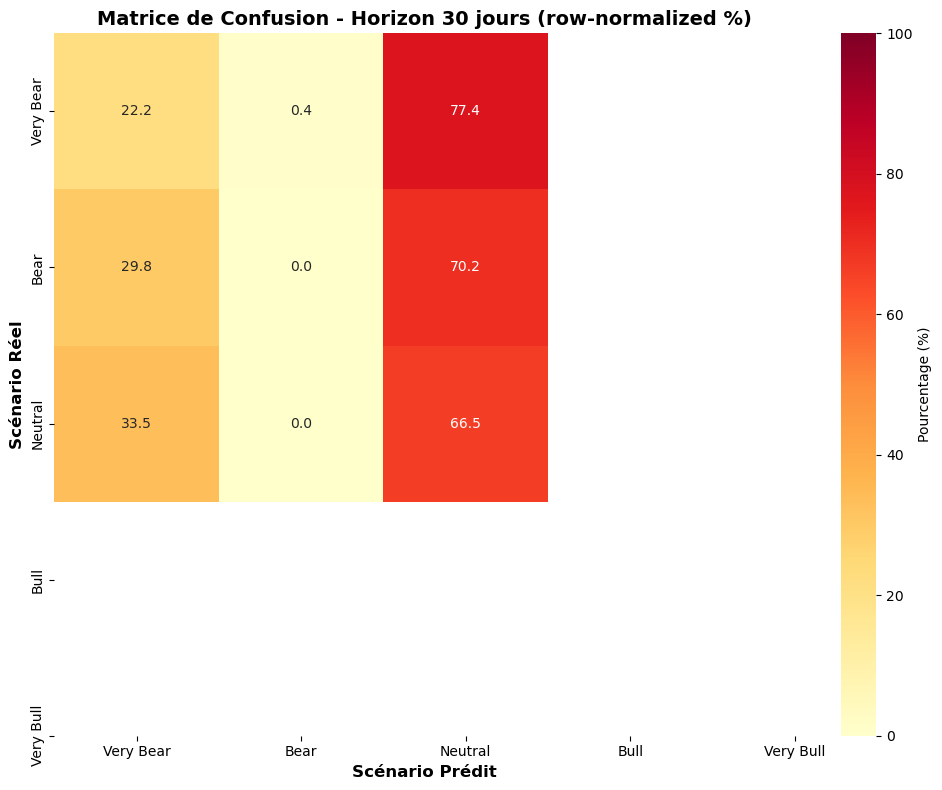


Matrice brute (counts):
[[ 53   1 185]
 [ 14   0  33]
 [120   0 238]]

Accuracy (from cm): 45.2%
Accuracy (from res['acc']): 45.2%
Balanced Accuracy (res['bal_acc']): 29.6%
Macro F1 (res['macro_f1']): 0.278


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Choisis l'horizon que tu veux voir
horizon_choisi = 30  # ex: 1, 14, 30, 60

# Trouve les résultats pour cet horizon
res = next((r for r in all_results if r["horizon"] == horizon_choisi), None)

if res is not None:
    # Récupère la matrice de confusion (dans ton nouveau code: clé = "cm")
    cm = np.array(res["cm"])

    # Noms des scénarios
    scenario_names = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

    # Normalise par ligne (pourcentage par classe réelle)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # évite division par 0 si une classe est absente
    cm_normalized = cm / row_sums * 100

    # Crée la figure
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        xticklabels=scenario_names,
        yticklabels=scenario_names,
        cbar_kws={"label": "Pourcentage (%)"},
        vmin=0,
        vmax=100
    )

    plt.xlabel("Scénario Prédit", fontsize=12, fontweight="bold")
    plt.ylabel("Scénario Réel", fontsize=12, fontweight="bold")
    plt.title(
        f"Matrice de Confusion - Horizon {horizon_choisi} jours (row-normalized %)",
        fontsize=14,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    # Matrice brute
    print("\nMatrice brute (counts):")
    print(cm)

    # Accuracy (tu peux aussi juste afficher res['acc'])
    accuracy = np.trace(cm) / np.sum(cm) * 100 if np.sum(cm) > 0 else 0.0
    print(f"\nAccuracy (from cm): {accuracy:.1f}%")
    print(f"Accuracy (from res['acc']): {res['acc']*100:.1f}%")
    print(f"Balanced Accuracy (res['bal_acc']): {res['bal_acc']*100:.1f}%")
    print(f"Macro F1 (res['macro_f1']): {res['macro_f1']:.3f}")

else:
    print(f"Pas de résultats pour horizon {horizon_choisi}j. Horizons dispo: {[r['horizon'] for r in all_results]}")


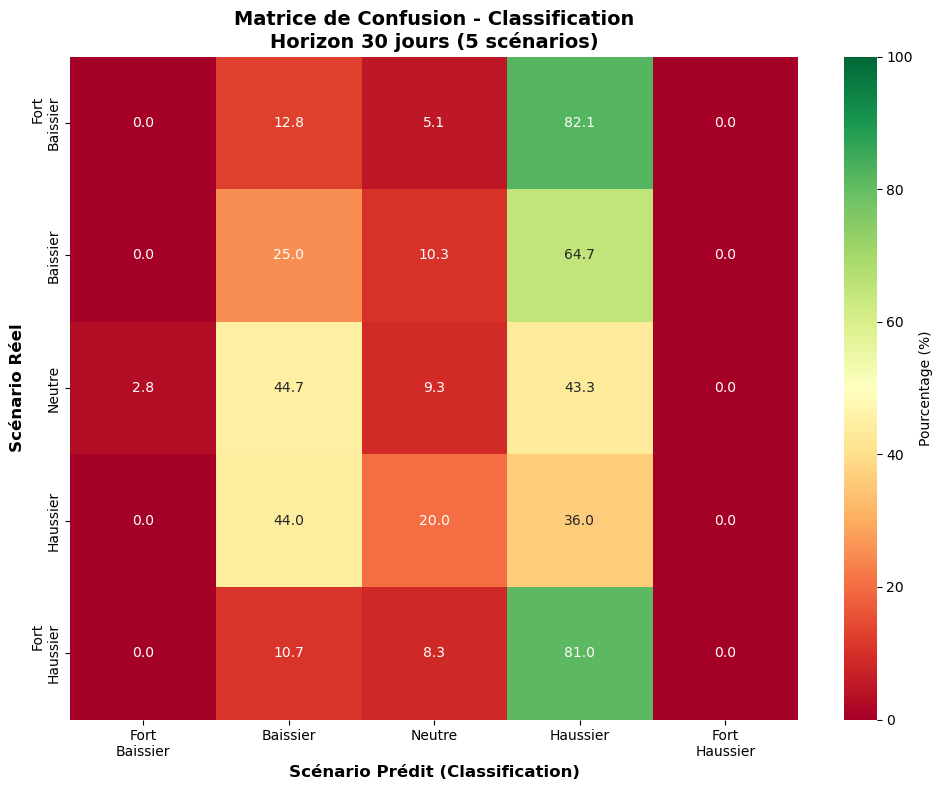


Accuracy (from cm): 17.5%
Accuracy (res['acc']): 17.5%
Balanced Accuracy (res['bal_acc']): 14.1%
Macro F1 (res['macro_f1']): 0.113
Nombre total d'échantillons: 644

Distribution des PRÉDICTIONS:
  Fort Baissier: 6 (0.9%)
  Baissier: 215 (33.4%)
  Neutre: 75 (11.6%)
  Haussier: 348 (54.0%)
  Fort Haussier: 0 (0.0%)

Distribution des RÉALITÉS:
  Fort Baissier: 39 (6.1%)
  Baissier: 156 (24.2%)
  Neutre: 215 (33.4%)
  Haussier: 150 (23.3%)
  Fort Haussier: 84 (13.0%)


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Choisis ton horizon
horizon_choisi = 30  # 1, 14, 30, 60

# Trouve les résultats
res = next((r for r in all_results if r["horizon"] == horizon_choisi), None)

if res is None:
    print(f"Pas de résultats pour horizon {horizon_choisi}j. Horizons dispo: {[r['horizon'] for r in all_results]}")
else:
    # Dans ton nouveau code leak-free: la clé s'appelle "cm"
    cm = np.array(res["cm"])

    # Noms fixes (toujours 5 scénarios)
    scenario_names = ["Fort Baissier", "Baissier", "Neutre", "Haussier", "Fort Haussier"]
    scenario_names_plot = [s.replace(" ", "\n") for s in scenario_names]

    # Normalisation par ligne (% par classe réelle)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # évite division par 0 si classe absente
    cm_normalized = cm / row_sums * 100

    # Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn",
        xticklabels=scenario_names_plot,
        yticklabels=scenario_names_plot,
        cbar_kws={"label": "Pourcentage (%)"},
        vmin=0, vmax=100
    )

    plt.xlabel("Scénario Prédit (Classification)", fontsize=12, fontweight="bold")
    plt.ylabel("Scénario Réel", fontsize=12, fontweight="bold")
    plt.title(f"Matrice de Confusion - Classification\nHorizon {horizon_choisi} jours (5 scénarios)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Stats cohérentes
    total = cm.sum()
    accuracy_from_cm = (np.trace(cm) / total * 100) if total > 0 else 0.0

    print(f"\nAccuracy (from cm): {accuracy_from_cm:.1f}%")
    print(f"Accuracy (res['acc']): {res['acc']*100:.1f}%")
    print(f"Balanced Accuracy (res['bal_acc']): {res['bal_acc']*100:.1f}%")
    print(f"Macro F1 (res['macro_f1']): {res['macro_f1']:.3f}")
    print(f"Nombre total d'échantillons: {int(total)}")

    # Distribution prédictions
    print("\nDistribution des PRÉDICTIONS:")
    pred_dist = cm.sum(axis=0)
    for i, v in enumerate(pred_dist):
        pct = (v / pred_dist.sum() * 100) if pred_dist.sum() > 0 else 0.0
        print(f"  {scenario_names[i]}: {int(v)} ({pct:.1f}%)")

    # Distribution réalités
    print("\nDistribution des RÉALITÉS:")
    real_dist = cm.sum(axis=1)
    for i, v in enumerate(real_dist):
        pct = (v / real_dist.sum() * 100) if real_dist.sum() > 0 else 0.0
        print(f"  {scenario_names[i]}: {int(v)} ({pct:.1f}%)")

    # Classes absentes (réel)
    absent_real = [scenario_names[i] for i in range(5) if real_dist[i] == 0]
    if absent_real:
        print("\nScénarios ABSENTS du test set (en réel):")
        for m in absent_real:
            print(f"  - {m}")


## Scénarios de rendement MEAN/STD 
En complément de l’approche par quantiles, nous considérons une définition alternative des
scénarios de rendement fondée sur la **moyenne et l’écart-type des rendements futurs**.

Pour un horizon donné, les rendements futurs du Bitcoin sont classés en cinq scénarios selon
leur écart à la moyenne observée sur la période d’entraînement :

- Very Bear : rendement < μ − 1σ  
- Bear : μ − 1σ ≤ rendement < μ − 0.5σ  
- Neutral : μ − 0.5σ ≤ rendement ≤ μ + 0.5σ  
- Bull : μ + 0.5σ < rendement ≤ μ + 1σ  
- Very Bull : rendement > μ + 1σ  

Les paramètres μ (moyenne) et σ (écart-type) sont **calculés exclusivement sur le jeu
d’entraînement**, puis appliqués au jeu de test, afin de garantir l’absence de fuite
d’information.

Cette approche permet d’interpréter les scénarios comme des **déviations absolues autour
d’un régime moyen**, mais peut conduire à des classes déséquilibrées dans le cas de
distributions asymétriques ou à queues épaisses, comme c’est le cas pour les rendements
financiers.

In [15]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"

SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

MIN_NON_NA_FRAC = 0.70
MIN_ROWS = 300

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type="simple"):
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)

    if return_type == "simple":
        return (future_price - prices) / prices
    else:
        return np.log(future_price / prices)

# ============================================================
# SCENARIOS: MEAN / STD (TRAIN ONLY)
# ============================================================

def fit_mean_std_thresholds(train_returns: pd.Series):
    x = train_returns.dropna()
    if len(x) < 50:
        raise ValueError("Not enough data for mean/std")
    return {"mu": float(x.mean()), "sigma": float(x.std())}

def apply_mean_std_scenarios(returns: pd.Series, thresholds: dict):
    mu, sigma = thresholds["mu"], thresholds["sigma"]
    s = pd.Series(index=returns.index, dtype="Int64")

    s[returns < mu - 1.0 * sigma] = 0
    s[(returns >= mu - 1.0 * sigma) & (returns < mu - 0.5 * sigma)] = 1
    s[(returns >= mu - 0.5 * sigma) & (returns <= mu + 0.5 * sigma)] = 2
    s[(returns > mu + 0.5 * sigma) & (returns <= mu + 1.0 * sigma)] = 3
    s[returns > mu + 1.0 * sigma] = 4

    return s

# ============================================================
# EVALUATION FUNCTION (LEAKAGE-FREE, DATE SPLIT)
# ============================================================

def evaluate_horizon_mean_std(
    pivot_df: pd.DataFrame,
    horizon: int
):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= START_DATE]

    btc_col = "XBTUSD Curncy" if "XBTUSD Curncy" in df.columns else "XBTUSD"

    # ---------- Features ----------
    df_feat = df.ffill()
    thresh = int(MIN_NON_NA_FRAC * len(df_feat))
    df_feat = df_feat.dropna(axis=1, thresh=thresh)

    # ---------- Target ----------
    returns = calculate_returns(df[btc_col], horizon, RETURN_TYPE)

    df_model = df_feat.copy()
    df_model["target_return"] = returns
    df_model = df_model.dropna(subset=["target_return"])

    if len(df_model) < MIN_ROWS:
        return None

    # ---------- Date split ----------
    cut = pd.to_datetime(TRAIN_END_DATE)
    train_mask = df_model.index <= cut
    test_mask = df_model.index > cut

    if train_mask.sum() < MIN_ROWS or test_mask.sum() < 50:
        return None

    X = df_model.drop(columns=["target_return"])
    y = df_model["target_return"]

    # Remove BTC level
    if btc_col in X.columns:
        X = X.drop(columns=[btc_col])

    # Split
    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train_ret, y_test_ret = y.loc[train_mask], y.loc[test_mask]

    # ---------- Scenarios (train only) ----------
    thresholds = fit_mean_std_thresholds(y_train_ret)
    y_train = apply_mean_std_scenarios(y_train_ret, thresholds).dropna().astype(int)
    y_test = apply_mean_std_scenarios(y_test_ret, thresholds).dropna().astype(int)

    X_train = X_train.loc[y_train.index]
    X_test = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    # ---------- Scaling ----------
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # ---------- Model ----------
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    # ---------- Metrics ----------
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred, labels=range(5))

    # ---------- Feature importance ----------
    imp = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp["rank"] = np.arange(1, len(imp) + 1)

    return {
        "horizon": horizon,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,
        "imp_full": imp,
        "top_features": imp.head(10)
    }

# ============================================================
# RUN MULTI-HORIZONS
# ============================================================

print("=" * 95)
print("BTC SCENARIO CLASSIFICATION — MEAN / STD (LEAKAGE-FREE, DATE SPLIT)")
print(f"Train ≤ {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print("=" * 95)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print(f"\n{'='*95}\nHorizon = {h} days\n{'='*95}")
    res = evaluate_horizon_mean_std(pivot_df, h)

    if res is None:
        print("Not enough data.")
        continue

    all_results.append(res)

    print(f"Train={res['n_train']} | Test={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print("\nTop 10 features:")
    print(res["top_features"][["rank","feature","importance"]].to_string(index=False))

    for _, r in res["top_features"].iterrows():
        feature_tracker[r["feature"]].append((h, r["importance"]))

# ============================================================
# SUMMARY
# ============================================================

summary = pd.DataFrame([{
    "Horizon": r["horizon"],
    "Train N": r["n_train"],
    "Test N": r["n_test"],
    "Accuracy (%)": r["acc"] * 100,
    "Balanced Acc (%)": r["bal_acc"] * 100,
    "Macro F1": r["macro_f1"]
} for r in all_results])

print("\n" + "="*95)
print("SUMMARY")
print("="*95)
print(summary.to_string(index=False))


BTC SCENARIO CLASSIFICATION — MEAN / STD (LEAKAGE-FREE, DATE SPLIT)
Train ≤ 2023-12-31 | Test > 2023-12-31

Horizon = 1 days
Train=1938 | Test=673
Acc=62.3% | BalAcc=20.2% | MacroF1=0.159

Top 10 features:
 rank           feature  importance
    1 active_addr_ratio    0.017060
    2   hashrate_7d_pct    0.016987
    3     tx_per_second    0.015355
    4            BlkCnt    0.015198
    5    mempool_growth    0.015177
    6               NVT    0.015127
    7     XBNUSD Curncy    0.014620
    8     XLCUSD Curncy    0.013675
    9         AdrActCnt    0.013429
   10        NVT_Signal    0.013381

Horizon = 14 days
Train=2035 | Test=660
Acc=58.8% | BalAcc=20.0% | MacroF1=0.148

Top 10 features:
 rank              feature  importance
    1        XBNUSD Curncy    0.020421
    2        XETUSD Curncy    0.015886
    3        XLCUSD Curncy    0.015852
    4           CapMVRVCur    0.015338
    5 days_to_next_halving    0.015019
    6   days_since_halving    0.014535
    7       CPI XYOY Inde

## Loi de student
Dans cette approche, les rendements futurs du Bitcoin sont modélisés à l’aide d’une loi de Student afin de définir les différents scénarios de marché. La loi de Student est particulièrement adaptée aux séries financières car elle permet de mieux capturer les événements extrêmes (queues épaisses) que la loi normale. Les paramètres de la loi (degrés de liberté, moyenne et écart-type) sont estimés uniquement sur l’échantillon d’entraînement afin d’éviter toute fuite d’information. Les scénarios (« Very Bear » à « Very Bull ») sont ensuite définis à partir des quantiles théoriques de cette distribution ajustée, garantissant une classification robuste et cohérente face à la volatilité élevée des rendements financiers.

In [16]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from collections import defaultdict

from scipy.stats import t as student_t  # Student-t distribution

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"   # train <= this date, test > this date

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"          # "simple" or "log"

N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

MIN_NON_NA_FRAC = 0.70          # after ffill
MIN_ROWS = 300

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Student-t thresholds: equal-probability bins (same as quantiles, but from fitted Student-t)
# 5 bins -> probabilities [0, 0.2, 0.4, 0.6, 0.8, 1]
BIN_PROBS = np.linspace(0, 1, N_BINS + 1)

# ============================================================
# TARGET: FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)

    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

# ============================================================
# STUDENT-T BINNING (TRAIN-ONLY) -> NO LEAKAGE
# ============================================================

def fit_student_t_bins(train_returns: pd.Series, probs: np.ndarray) -> dict:
    """
    Fit a Student-t distribution on TRAIN returns only, then compute bin edges
    using the fitted distribution's quantiles.

    Returns a dict containing:
      - df, loc, scale (fitted params)
      - edges (np.ndarray) of length N_BINS+1 with [-inf, ..., +inf]
    """
    x = train_returns.dropna().astype(float).values
    if len(x) < 200:
        raise ValueError("Not enough training returns to fit Student-t robustly (need ~200+).")

    # Fit Student-t: returns df, loc, scale (MLE)
    df_hat, loc_hat, scale_hat = student_t.fit(x)

    # Compute edges from fitted distribution quantiles
    edges = student_t.ppf(probs, df_hat, loc=loc_hat, scale=scale_hat)
    edges[0], edges[-1] = -np.inf, np.inf

    # Guard against numerical non-monotonicity
    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = edges[i - 1] + 1e-12

    return {"df": df_hat, "loc": loc_hat, "scale": scale_hat, "edges": edges}

def apply_bins_from_edges(returns: pd.Series, edges: np.ndarray) -> pd.Series:
    """
    Apply precomputed edges to returns -> labels 0..N_BINS-1
    """
    return pd.cut(returns.astype(float), bins=edges, labels=False, include_lowest=True).astype("Int64")

# ============================================================
# EVALUATION (CLASSIFICATION ONLY, LEAKAGE SAFE, DATE SPLIT)
# ============================================================

def evaluate_horizon_student_t_by_date(
    pivot_df: pd.DataFrame,
    horizon: int,
    return_type: str = "simple",
    train_end_date: str = TRAIN_END_DATE,
    start_date: str = START_DATE
):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(start_date)]

    # Detect BTC column
    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("BTC column not found (expected 'XBTUSD Curncy' or 'XBTUSD').")

    # ---------- Features: ffill ONLY (NO bfill) ----------
    df_features = df.ffill()

    # Drop columns too incomplete after ffill
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    # ---------- Target returns ----------
    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    # Build model frame (features + target)
    df_model = df_features.copy()
    df_model["target_return"] = returns

    # Remove rows where future target not available
    df_model = df_model.dropna(subset=["target_return"])
    if len(df_model) < MIN_ROWS:
        return None

    # Date split
    cut = pd.to_datetime(train_end_date)
    train_mask = df_model.index <= cut
    test_mask = df_model.index > cut

    if train_mask.sum() < MIN_ROWS or test_mask.sum() < 50:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # Safety: remove return-like engineered columns if they exist
    X_full = X_full.drop(
        columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()],
        errors="ignore"
    )

    # Remove BTC level column exactly
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    # Split
    X_train = X_full.loc[train_mask].copy()
    X_test  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # ---------- Student-t bins fitted on TRAIN ONLY ----------
    tfit = fit_student_t_bins(y_ret_train, BIN_PROBS)
    edges = tfit["edges"]

    y_train = apply_bins_from_edges(y_ret_train, edges).dropna().astype(int)
    y_test  = apply_bins_from_edges(y_ret_test, edges).dropna().astype(int)

    # Align X with y indices (in case of dropped rows)
    X_train = X_train.loc[y_train.index]
    X_test  = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    # Scaling (fit train only)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Model
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # Metrics
    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

    # Feature importances (full)
    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    # Return stats
    ret_stats_train = {"mean": float(y_ret_train.mean()), "std": float(y_ret_train.std())}
    ret_stats_test  = {"mean": float(y_ret_test.mean()),  "std": float(y_ret_test.std())}

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": str(train_end_date),

        # Student-t params for reporting
        "student_t_df": float(tfit["df"]),
        "student_t_loc": float(tfit["loc"]),
        "student_t_scale": float(tfit["scale"]),
        "student_t_edges": edges,

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,

        "top_features": imp_full.head(10),
        "imp_full": imp_full,

        "ret_stats_train": ret_stats_train,
        "ret_stats_test": ret_stats_test
    }

# ============================================================
# RUN MULTI-HORIZONS + SUMMARY
# ============================================================

print("=" * 110)
print("MULTI-HORIZON BTC SCENARIO CLASSIFICATION (Student-t bins, leakage-free, DATE SPLIT)")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print("Bins: fitted Student-t on TRAIN returns, then 0/20/40/60/80/100% thresholds from fitted distribution")
print("=" * 110)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 110)
    print(f"Horizon = {h} days")
    print("=" * 110)

    res = evaluate_horizon_student_t_by_date(
        pivot_df,
        horizon=h,
        return_type=RETURN_TYPE,
        train_end_date=TRAIN_END_DATE,
        start_date=START_DATE
    )

    if res is None:
        print("-> Not enough data / too few usable features with this date split.")
        continue

    all_results.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Student-t fit (train): df={res['student_t_df']:.2f}, loc={res['student_t_loc']:.6f}, scale={res['student_t_scale']:.6f}")
    print("Student-t bin edges:", np.round(res["student_t_edges"], 6))
    print(f"Train N={res['n_train']} | Test N={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")

    print("\nTop 10 features:")
    print(res["top_features"][["rank","feature","importance"]].to_string(index=False))

    for _, row in res["imp_full"].head(10).iterrows():
        feature_tracker[row["feature"]].append((h, float(row["importance"])))

if all_results:
    summary_df = pd.DataFrame([{
        "Horizon (d)": r["horizon"],
        "Train N": r["n_train"],
        "Test N": r["n_test"],
        "Acc (%)": r["acc"] * 100,
        "BalAcc (%)": r["bal_acc"] * 100,
        "MacroF1": r["macro_f1"],
        "t_df": r["student_t_df"],
        "t_loc": r["student_t_loc"],
        "t_scale": r["student_t_scale"],
        "Train mean ret": r["ret_stats_train"]["mean"],
        "Train std ret": r["ret_stats_train"]["std"],
        "Test mean ret": r["ret_stats_test"]["mean"],
        "Test std ret": r["ret_stats_test"]["std"],
    } for r in all_results]).sort_values("Horizon (d)")

    print("\n" + "=" * 110)
    print("SUMMARY")
    print("=" * 110)
    print(summary_df.to_string(index=False))

    print("\n" + "=" * 110)
    print("MOST RECURRENT FEATURES (top-20 across horizons, from top-10 each horizon)")
    print("=" * 110)

    feat_counts = {feat: len(v) for feat, v in feature_tracker.items()}
    for feat, count in sorted(feat_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
        horizons_str = ", ".join([f"{h}d" for h, _ in feature_tracker[feat]])
        avg_imp = float(np.mean([imp for _, imp in feature_tracker[feat]]))
        print(f"{feat:35s} -> {count}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")
else:
    print("No results (all horizons failed).")

# ============================================================
# OPTIONAL: check ranks for specific features (RIOT, DXY)
# Example:
# r = all_results[0]
# r["imp_full"][r["imp_full"]["feature"].str.contains("RIOT|DXY", case=False, na=False)][["rank","feature","importance"]]
# ============================================================


MULTI-HORIZON BTC SCENARIO CLASSIFICATION (Student-t bins, leakage-free, DATE SPLIT)
Train <= 2023-12-31 | Test > 2023-12-31
Bins: fitted Student-t on TRAIN returns, then 0/20/40/60/80/100% thresholds from fitted distribution

Horizon = 1 days
BTC col used: XBTUSD Curncy
Student-t fit (train): df=2.27, loc=0.000746, scale=0.019570
Student-t bin edges: [     -inf -0.019424 -0.004821  0.006312  0.020915       inf]
Train N=1938 | Test N=673
Acc=22.4% | BalAcc=19.9% | MacroF1=0.124

Top 10 features:
 rank           feature  importance
    1   hashrate_7d_pct    0.020073
    2 active_addr_ratio    0.018081
    3            BlkCnt    0.016450
    4          TxTfrCnt    0.016092
    5     XLCUSD Curncy    0.015766
    6               NVT    0.015243
    7         AdrActCnt    0.014577
    8     XBNUSD Curncy    0.014546
    9    mempool_growth    0.013904
   10             TxCnt    0.013818

Horizon = 14 days
BTC col used: XBTUSD Curncy
Student-t fit (train): df=4.09, loc=0.011845, scale=0.10

## Loi de Pareto
Cette approche s’appuie sur la loi de Pareto pour modéliser spécifiquement les rendements extrêmes du Bitcoin, c’est-à-dire les variations les plus fortes à la hausse ou à la baisse. La loi de Pareto est utilisée uniquement sur les queues de la distribution, au-delà d’un seuil élevé défini sur les données d’entraînement. Les rendements extrêmes positifs et négatifs sont ainsi traités séparément, tandis que la partie centrale de la distribution est conservée telle quelle. Cette méthode permet de mieux caractériser les phases de marché rares mais économiquement significatives, en mettant l’accent sur les chocs majeurs plutôt que sur les fluctuations ordinaires.

In [17]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from collections import defaultdict

from scipy.stats import t as student_t
from scipy.stats import pareto

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"   # "simple" or "log"

N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

MIN_NON_NA_FRAC = 0.70
MIN_ROWS = 300

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

BIN_PROBS = np.linspace(0, 1, N_BINS + 1)  # [0, .2, .4, .6, .8, 1]

# ============================================================
# TARGET: FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)
    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

def apply_bins_from_edges(returns: pd.Series, edges: np.ndarray) -> pd.Series:
    return pd.cut(returns.astype(float), bins=edges, labels=False, include_lowest=True).astype("Int64")

def _monotone_edges(edges: np.ndarray) -> np.ndarray:
    edges = edges.astype(float).copy()
    edges[0], edges[-1] = -np.inf, np.inf
    for i in range(1, len(edges)):
        if edges[i] <= edges[i-1]:
            edges[i] = edges[i-1] + 1e-12
    return edges

# ============================================================
# STUDENT-T BINS (TRAIN ONLY)
# ============================================================

def fit_student_t_edges(train_returns: pd.Series, probs: np.ndarray) -> dict:
    x = train_returns.dropna().astype(float).values
    if len(x) < 200:
        raise ValueError("Not enough training returns to fit Student-t robustly (need ~200+).")
    df_hat, loc_hat, scale_hat = student_t.fit(x)
    edges = student_t.ppf(probs, df_hat, loc=loc_hat, scale=scale_hat)
    edges = _monotone_edges(edges)
    return {"method": "student_t", "df": df_hat, "loc": loc_hat, "scale": scale_hat, "edges": edges}

# ============================================================
# PARETO TAIL BINS (TRAIN ONLY)
#   - central bins from empirical quantiles (q20,q40,q60,q80)
#   - replace extreme tails using fitted Pareto on:
#       upper tail: (r - u_high) for r >= u_high
#       lower tail: (-r - u_low) for r <= -u_low_threshold (i.e. very negative)
# ============================================================

def fit_pareto_tail_edges(train_returns: pd.Series,
                          probs: np.ndarray,
                          tail_u_prob: float = 0.80,
                          min_tail_n: int = 80) -> dict:
    """
    Build 5-bin edges:
      [-inf, edge20, edge40, edge60, edge80, +inf]
    where edge20/40/60/80 come mostly from empirical quantiles,
    but edge20 and edge80 can be "tail-adjusted" using Pareto fitted on tails.

    tail_u_prob = threshold quantile for defining the tail (e.g. 0.80 means top 20% is tail for upper side)
    """
    x = train_returns.dropna().astype(float)
    if len(x) < 500:
        raise ValueError("Not enough training returns to fit Pareto tails robustly (need ~500+).")

    # Base empirical edges (balanced bins on train)
    q_edges = np.quantile(x.values, probs)
    # We'll potentially replace q_edges[1] (20%) and q_edges[4] (80%) using Pareto tail fits.
    # Keep middle edges as empirical:
    edge40 = q_edges[2]
    edge60 = q_edges[3]

    # -------- Upper tail fit --------
    u_high = np.quantile(x.values, tail_u_prob)
    upper = x[x >= u_high]
    upper_excess = (upper - u_high).values  # >=0

    # -------- Lower tail fit (on negative side) --------
    # Define a threshold for large negative moves using symmetric probability (1-tail_u_prob)
    u_low = -np.quantile((-x).values, tail_u_prob)  # negative threshold
    lower = x[x <= u_low]
    lower_excess = ((-lower) - (-u_low)).values  # >=0 (amount beyond threshold)

    # Initialize edges from empirical
    edge20 = q_edges[1]
    edge80 = q_edges[4]

    pareto_params = {}

    # Fit Pareto on upper excess if enough points
    if len(upper_excess) >= min_tail_n and np.all(upper_excess >= 0):
        # pareto.fit returns shape(b), loc, scale; for excess we force loc=0 (more stable)
        b_u, loc_u, scale_u = pareto.fit(upper_excess, floc=0)
        # Replace the 80% threshold using Pareto-implied quantile for p=0.80 within full distribution:
        # Within our scheme, edge80 is just the boundary between bin3 and bin4.
        # But to use tail model, we compute the (tail_u_prob) quantile by definition is u_high,
        # so it doesn't change; instead we can refine the boundary at 80% by choosing u_high itself
        # OR slightly adjust to match the same bin prob. Practical: keep edge80 = u_high (more principled).
        edge80 = float(u_high)
        pareto_params["upper"] = {"b": float(b_u), "scale": float(scale_u), "u": float(u_high), "n": int(len(upper_excess))}
    else:
        pareto_params["upper"] = {"skipped": True, "n": int(len(upper_excess))}

    # Fit Pareto on lower excess if enough points
    if len(lower_excess) >= min_tail_n and np.all(lower_excess >= 0):
        b_l, loc_l, scale_l = pareto.fit(lower_excess, floc=0)
        # Similarly, take edge20 as the lower tail threshold u_low
        edge20 = float(u_low)
        pareto_params["lower"] = {"b": float(b_l), "scale": float(scale_l), "u": float(u_low), "n": int(len(lower_excess))}
    else:
        pareto_params["lower"] = {"skipped": True, "n": int(len(lower_excess))}

    edges = np.array([-np.inf, edge20, edge40, edge60, edge80, np.inf], dtype=float)
    edges = _monotone_edges(edges)

    return {"method": "pareto_tails", "edges": edges, "tail_u_prob": tail_u_prob, "min_tail_n": min_tail_n, "params": pareto_params}

# ============================================================
# CORE EVALUATION (shared)
# ============================================================

def evaluate_horizon_by_date_with_edges(
    pivot_df: pd.DataFrame,
    horizon: int,
    edges_fitter,                 # function(train_returns)-> dict with "edges"
    return_type: str = "simple",
    train_end_date: str = TRAIN_END_DATE,
    start_date: str = START_DATE
):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(start_date)]

    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("BTC column not found (expected 'XBTUSD Curncy' or 'XBTUSD').")

    # Features: ffill only
    df_features = df.ffill()
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    df_model = df_features.copy()
    df_model["target_return"] = returns
    df_model = df_model.dropna(subset=["target_return"])
    if len(df_model) < MIN_ROWS:
        return None

    cut = pd.to_datetime(train_end_date)
    train_mask = df_model.index <= cut
    test_mask = df_model.index > cut
    if train_mask.sum() < MIN_ROWS or test_mask.sum() < 50:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # safety removals
    X_full = X_full.drop(
        columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()],
        errors="ignore"
    )
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    X_train = X_full.loc[train_mask].copy()
    X_test  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # Fit edges on train only
    fit_info = edges_fitter(y_ret_train)
    edges = fit_info["edges"]

    y_train = apply_bins_from_edges(y_ret_train, edges).dropna().astype(int)
    y_test  = apply_bins_from_edges(y_ret_test, edges).dropna().astype(int)

    X_train = X_train.loc[y_train.index]
    X_test  = X_test.loc[y_test.index]
    if X_train.shape[1] < 5:
        return None

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    return {
        "method": fit_info.get("method", "custom"),
        "fit_info": fit_info,
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": str(train_end_date),

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,

        "top_features": imp_full.head(10),
        "imp_full": imp_full,

        "train_mean_ret": float(y_ret_train.mean()),
        "train_std_ret": float(y_ret_train.std()),
        "test_mean_ret": float(y_ret_test.mean()),
        "test_std_ret": float(y_ret_test.std()),
    }

# ============================================================
# RUN: Student-t then Pareto tails
# ============================================================

def run_experiment(method_name: str, edges_fitter):
    print("\n" + "=" * 120)
    print(f"METHOD = {method_name} | leakage-free | date split train<={TRAIN_END_DATE} test>{TRAIN_END_DATE}")
    print("=" * 120)

    results = []
    feat_track = defaultdict(list)

    for h in HORIZONS:
        print("\n" + "-" * 120)
        print(f"Horizon={h}d")
        print("-" * 120)

        res = evaluate_horizon_by_date_with_edges(
            pivot_df,
            horizon=h,
            edges_fitter=edges_fitter,
            return_type=RETURN_TYPE,
            train_end_date=TRAIN_END_DATE,
            start_date=START_DATE
        )

        if res is None:
            print("-> Not enough data / too few features.")
            continue

        results.append(res)

        print(f"BTC: {res['btc_col_used']} | Train={res['n_train']} | Test={res['n_test']}")
        print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
        print("Edges:", np.round(res["fit_info"]["edges"], 6))

        # Print fit params if available
        if res["method"] == "student_t":
            fi = res["fit_info"]
            print(f"Student-t fit: df={fi['df']:.2f}, loc={fi['loc']:.6f}, scale={fi['scale']:.6f}")
        if res["method"] == "pareto_tails":
            fi = res["fit_info"]
            print("Pareto tails fit info:", fi["params"])

        print("\nTop 10 features:")
        print(res["top_features"][["rank", "feature", "importance"]].to_string(index=False))

        for _, row in res["imp_full"].head(10).iterrows():
            feat_track[row["feature"]].append((h, float(row["importance"])))

    if results:
        summary = pd.DataFrame([{
            "Method": r["method"],
            "Horizon(d)": r["horizon"],
            "Train N": r["n_train"],
            "Test N": r["n_test"],
            "Acc(%)": r["acc"]*100,
            "BalAcc(%)": r["bal_acc"]*100,
            "MacroF1": r["macro_f1"],
            "Train mean": r["train_mean_ret"],
            "Train std": r["train_std_ret"],
            "Test mean": r["test_mean_ret"],
            "Test std": r["test_std_ret"],
        } for r in results]).sort_values(["Horizon(d)"])

        print("\n" + "=" * 120)
        print("SUMMARY")
        print("=" * 120)
        print(summary.to_string(index=False))

        print("\n" + "=" * 120)
        print("MOST RECURRENT FEATURES (top-20 across horizons, from top-10 each horizon)")
        print("=" * 120)
        counts = {k: len(v) for k, v in feat_track.items()}
        for feat, c in sorted(counts.items(), key=lambda x: x[1], reverse=True)[:20]:
            horizons_str = ", ".join([f"{h}d" for h, _ in feat_track[feat]])
            avg_imp = float(np.mean([imp for _, imp in feat_track[feat]]))
            print(f"{feat:35s} -> {c}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")

    return results

# Student-t experiment
student_results = run_experiment(
    "Student-t quantile edges (fitted on train)",
    edges_fitter=lambda y_train: fit_student_t_edges(y_train, BIN_PROBS)
)

# Pareto tails experiment
pareto_results = run_experiment(
    "Pareto tails + empirical middle edges (train-only)",
    edges_fitter=lambda y_train: fit_pareto_tail_edges(y_train, BIN_PROBS, tail_u_prob=0.80, min_tail_n=80)
)



METHOD = Student-t quantile edges (fitted on train) | leakage-free | date split train<=2023-12-31 test>2023-12-31

------------------------------------------------------------------------------------------------------------------------
Horizon=1d
------------------------------------------------------------------------------------------------------------------------
BTC: XBTUSD Curncy | Train=1938 | Test=673
Acc=22.4% | BalAcc=19.9% | MacroF1=0.124
Edges: [     -inf -0.019424 -0.004821  0.006312  0.020915       inf]
Student-t fit: df=2.27, loc=0.000746, scale=0.019570

Top 10 features:
 rank           feature  importance
    1   hashrate_7d_pct    0.020073
    2 active_addr_ratio    0.018081
    3            BlkCnt    0.016450
    4          TxTfrCnt    0.016092
    5     XLCUSD Curncy    0.015766
    6               NVT    0.015243
    7         AdrActCnt    0.014577
    8     XBNUSD Curncy    0.014546
    9    mempool_growth    0.013904
   10             TxCnt    0.013818

----------

## 3 scénarios

In [18]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"

THRESH_NEUTRAL = 0.01
SCENARIO_NAMES = ["Bear", "Neutral", "Bull"]

MIN_NON_NA_FRAC = 0.70
MIN_ROWS_TOTAL = 300
MIN_ROWS_TRAIN = 300
MIN_ROWS_TEST = 50

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# FEATURE ENGINEERING
# ============================================================

def enrich_features(df):
    df = df.copy()
    if "mempool_count" in df.columns:
        df["mempool_growth"] = df["mempool_count"].pct_change().replace([np.inf, -np.inf], np.nan)
    if "AdrActCnt" in df.columns and "TxCnt" in df.columns:
        df["tx_per_addr"] = df["TxCnt"] / df["AdrActCnt"]
    if "BlkSizeMean" in df.columns and "BlkCnt" in df.columns:
        df["avg_block_size"] = df["BlkSizeMean"] / df["BlkCnt"]
    return df

# ============================================================
# TARGET BINNING (3 classes based on thresholds)
# ============================================================

def binarize_return_thresholds(ret: pd.Series, thresh: float = 0.01) -> pd.Series:
    return pd.cut(ret,
                  bins=[-np.inf, -thresh, thresh, np.inf],
                  labels=[0, 1, 2], include_lowest=True).astype("Int64")

# ============================================================
# MAIN MODELING FUNCTION
# ============================================================

def evaluate_rf_btc_threshold_based(pivot_df: pd.DataFrame, horizon: int, return_type: str = "simple"):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]

    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("Colonne BTC introuvable.")

    df = enrich_features(df)
    df_features = df.ffill()
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)
    df_model = df_features.copy()
    df_model["target_return"] = returns
    df_model = df_model.dropna(subset=["target_return"])

    if len(df_model) < MIN_ROWS_TOTAL:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    X_full = X_full.drop(columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()], errors="ignore")
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    cut = pd.to_datetime(TRAIN_END_DATE)
    train_mask = X_full.index <= cut
    test_mask = X_full.index > cut

    if train_mask.sum() < MIN_ROWS_TRAIN or test_mask.sum() < MIN_ROWS_TEST:
        return None

    X_train = X_full.loc[train_mask].copy()
    X_test = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test = y_ret_full.loc[test_mask].copy()

    y_train = binarize_return_thresholds(y_ret_train, thresh=THRESH_NEUTRAL).dropna().astype(int)
    y_test = binarize_return_thresholds(y_ret_test, thresh=THRESH_NEUTRAL).dropna().astype(int)

    X_train = X_train.loc[y_train.index]
    X_test = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(3)))

    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train_scaled, y_train)
    y_dummy = dummy.predict(X_test_scaled)

    dummy_acc = float(accuracy_score(y_test, y_dummy))
    dummy_bal_acc = float(balanced_accuracy_score(y_test, y_dummy))
    dummy_macro_f1 = float(f1_score(y_test, y_dummy, average="macro"))

    imp = pd.DataFrame({"feature": X_train.columns, "importance": clf.feature_importances_})
    imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)
    imp["rank"] = np.arange(1, len(imp) + 1)

    dist_test = y_test.value_counts().sort_index()

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,
        "dummy_acc": dummy_acc,
        "dummy_bal_acc": dummy_bal_acc,
        "dummy_macro_f1": dummy_macro_f1,
        "top_features": imp.head(10),
        "imp_full": imp,
        "dist_test": dist_test
    }

# ============================================================
# MAIN EXECUTION
# ============================================================

print("=" * 95)
print("CLASSIFICATION BTC – 3 SCÉNARIOS (Bear / Neutral / Bull) – SÉPARATION TEMPORALE")
print("=" * 95)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 95)
    print(f"Horizon = {h} days")
    print("=" * 95)

    res = evaluate_rf_btc_threshold_based(pivot_df, h, return_type=RETURN_TYPE)
    if res is None:
        print("-> Not enough data / features.")
        continue

    all_results.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Train={res['n_train']} | Test={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print(f"Dummy Acc={res['dummy_acc']*100:.1f}% | Dummy BalAcc={res['dummy_bal_acc']*100:.1f}% | Dummy MacroF1={res['dummy_macro_f1']:.3f}")

    print("\nTest Scenario Distribution:")
    total = res["dist_test"].sum()
    for i in range(3):
        name = SCENARIO_NAMES[i]
        val = int(res["dist_test"].get(i, 0))
        print(f"  {i} {name:<8}: {val:4d} ({val/total*100:.1f}%)")

    print("\nTop 10 Features:")
    print(res["top_features"]["rank feature importance".split()].to_string(index=False))

    for _, row in res["top_features"].iterrows():
        feature_tracker[row["feature"]].append((h, row["importance"]))


CLASSIFICATION BTC – 3 SCÉNARIOS (Bear / Neutral / Bull) – SÉPARATION TEMPORALE

Horizon = 1 days
BTC col used: XBTUSD Curncy
Train=1938 | Test=673
Acc=38.9% | BalAcc=33.4% | MacroF1=0.210
Dummy Acc=39.1% | Dummy BalAcc=33.3% | Dummy MacroF1=0.187

Test Scenario Distribution:
  0 Bear    :  195 (29.0%)
  1 Neutral :  263 (39.1%)
  2 Bull    :  215 (31.9%)

Top 10 Features:
 rank           feature  importance
    1   hashrate_7d_pct    0.018623
    2 active_addr_ratio    0.016502
    3     XBNUSD Curncy    0.016230
    4         AdrActCnt    0.015237
    5            BlkCnt    0.015135
    6     tx_per_second    0.015119
    7      GJGB3M Index    0.014511
    8          TxTfrCnt    0.014504
    9          HashRate    0.014301
   10     XLCUSD Curncy    0.013626

Horizon = 14 days
BTC col used: XBTUSD Curncy
Train=2035 | Test=660
Acc=50.6% | BalAcc=33.5% | MacroF1=0.227
Dummy Acc=50.5% | Dummy BalAcc=33.3% | Dummy MacroF1=0.224

Test Scenario Distribution:
  0 Bear    :  248 (37.6%)
  1

## Causalité

In [19]:
print(pivot_df.columns.tolist())

['AdrActCnt', 'BASPTDSP Index', 'BDIY Index', 'BOJDPBAL Index', 'BlkCnt', 'CCMP Index', 'CESICNY Index', 'CESIEUR Index', 'CESIJPY Index', 'CESIUSD Index', 'CFC5QNCN Index', 'CFC5QOIN Index', 'CFC5RCOL Index', 'CFC5RNCN Index', 'CFC5ROIN Index', 'CFC5RTCL Index', 'CFF5QOIN Index', 'CFF5RCON Index', 'CFF5RNCL Index', 'CFF5RNCN Index', 'CFF5RNCS Index', 'CFF5RNRN Index', 'CFF5ROIN Index', 'CFF5RTLL Index', 'CFF5RTLN Index', 'CFF5RTLS Index', 'CHRRDEPC Index', 'CHVAICY Index', 'CIFR US Equity', 'CL1 COMB Comdty', 'CNBMTTAS Index', 'CNCPCRY Index', 'CNH Curncy', 'CNMSM2 Index', 'CNRSCONS Index', 'CO1 COMB Comdty', 'CORZ US Equity', 'CPEXEMUY Index', 'CPI XYOY Index', 'CRY Index', 'CVIX Index', 'CapMVRVCur', 'DEYC2Y10 Index', 'DXY Curncy', 'EBBSTOTA Index', 'ECMAM2 Index', 'EUITEMU Index', 'EURR002W Index', 'EURUSD Curncy', 'European_News_Index', 'FARBAST Index', 'FDTR Index', 'France_News_Index', 'GCNY3M Index', 'GETB1 Index', 'GJGB3M Index', 'Germany_News_Index', 'HashRate', 'IP Index', '

In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from dowhy import CausalModel

# ============================================================
# 1. PRÉTRAITEMENT : Nettoyage, création des variables
# ============================================================

# Vérification du nom de la colonne BTC
btc_col = "XBTUSD Curncy"
if btc_col not in pivot_df.columns:
    raise ValueError("Colonne de prix BTC 'XBTUSD Curncy' introuvable dans pivot_df")

# Calcul du rendement futur BTC (30 jours)
pivot_df["btc_return_30d"] = np.log(pivot_df[btc_col].shift(-30) / pivot_df[btc_col])

# Calcul de hashrate_7d_pct si HashRate est présent
if "HashRate" in pivot_df.columns:
    pivot_df["hashrate_7d_pct"] = pivot_df["HashRate"].pct_change(periods=7) * 100
else:
    pivot_df["hashrate_7d_pct"] = np.nan
    print(" 'HashRate' non présent. La variable hashrate_7d_pct sera NaN.")

# Drop des lignes incomplètes
pivot_df.dropna(subset=["btc_return_30d", "hashrate_7d_pct"], inplace=True)

# ============================================================
# 2. GRANGER CAUSALITY TEST
# ============================================================

features = ["hashrate_7d_pct", "CapMVRVCur", "XBNUSD Curncy"]

print("=" * 60)
print("TEST DE CAUSALITÉ DE GRANGER")
print("=" * 60)

maxlag = 7
for var in features:
    print(f"\n{var} -> btc_return_14d")
    try:
        data = pivot_df[["btc_return_30d", var]].dropna()
        result = sm.tsa.stattools.grangercausalitytests(data, maxlag=maxlag, verbose=False)
        p_values = [round(result[lag][0]["ssr_ftest"][1], 4) for lag in range(1, maxlag + 1)]
        min_p = min(p_values)
        best_lag = p_values.index(min_p) + 1
        print(f"P-values (lags 1 à {maxlag}): {p_values}")
        if min_p < 0.05:
            print(f"-> Causalité détectée au lag {best_lag} (p={min_p})")
        else:
            print(f"-> Pas de causalité de Granger significative (p_min={min_p})")
    except Exception as e:
        print(f"Erreur pour {var}: {e}")

# ============================================================
# 3. ESTIMATION CAUSALE AVEC DOWHY
# ============================================================

print("\n" + "=" * 60)
print("ESTIMATION CAUSALE (DoWhy)")
print("=" * 60)

# Colonnes à utiliser
cols_needed = [
    "btc_return_30d",
    "XBNUSD Curncy",
    "CapMVRVCur",
    "hashrate_7d_pct",
    "days_to_next_halving",
    "LUATTRUU Index"
]

# Vérifier leur présence réelle
available_cols = [col for col in cols_needed if col in pivot_df.columns]
pivot_df_clean = pivot_df[available_cols].replace([np.inf, -np.inf], np.nan).dropna()

# Remplacer les espaces par underscores pour DoWhy
pivot_df_clean = pivot_df_clean.rename(columns={
    "XBNUSD Curncy": "XBNUSD_Curncy",
    "LUATTRUU Index": "LUATTRUU_Index"
})
pivot_df = pivot_df_clean.copy()

# Graphe causal
causal_graph = """
digraph {
    XBNUSD_Curncy -> btc_return_30d;
    CapMVRVCur -> btc_return_30d;
    hashrate_7d_pct -> btc_return_30d;
    days_to_next_halving -> btc_return_30d;
    LUATTRUU_Index -> btc_return_30d;
}
"""

# Fonction d’estimation ATE
def estimate_ate(treatment: str):
    try:
        model = CausalModel(
            data=pivot_df,
            treatment=treatment,
            outcome="btc_return_30d",
            graph=causal_graph
        )
        identified_estimand = model.identify_effect()
        estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
        print(f"ATE estimé de {treatment} sur btc_return_30d: {estimate.value:.6f}")
        model.view_model()
    except Exception as e:
        print(f"[Erreur ATE] {treatment} -> {e}")

# Lancer les estimations
treatments = ["XBNUSD_Curncy", "CapMVRVCur", "hashrate_7d_pct", "days_to_next_halving", "LUATTRUU_Index"]

for var in treatments:
    estimate_ate(var)


ModuleNotFoundError: No module named 'dowhy'

Dans les résultats précédemment obtenus, nous avons appliqué une analyse de causalité entre plusieurs variables explicatives (ou "features") et les rendements futurs du Bitcoin à 14 jours (btc_return_14d). Concrètement, cela signifie que nous cherchions à identifier si certaines variables, comme hashrate_7d_pct, CapMVRVCur ou XBNUSD Curncy, avaient une influence causale sur l'évolution du prix du Bitcoin deux semaines plus tard.

Pour cela, deux méthodes complémentaires ont été utilisées :

Le test de Granger : pour détecter si une variable passée aide statistiquement à prédire les rendements futurs. Ce test a mis en évidence une causalité temporelle pour les trois variables analysées (avec des lags significatifs différents).

Le framework causal DoWhy : qui, à partir d’un graphe causal défini manuellement, a permis d’estimer l’effet de traitement moyen (ATE) de chaque variable sur btc_return_14d, en isolant les biais potentiels de confusion.

En résumé, on a donc cherché à identifier des relations de causalité économique structurelle et temporelle entre certains indicateurs et les rendements du BTC à 14 jours.

## test causality

In [ ]:
# ===============================
# CAUSAL PIPELINE (DoWhy) - VERSION CORRIGÉE v2
# ===============================

import pandas as pd
import numpy as np

# 1) Base DF
df = pivot_df.copy()

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# 2) Create BTC log-return + horizon target (choose one)
HORIZON = 7  # change to 1, 7, 30, etc.

if "XBTUSD Curncy" not in df.columns:
    raise ValueError("BTC price column 'XBTUSD Curncy' missing.")

df["BTC_logret"] = np.log(df["XBTUSD Curncy"]).diff()

# Target = cumulative log-return over next HORIZON days
df["target"] = df["BTC_logret"].rolling(HORIZON).sum().shift(-HORIZON)

# Drop only where target or BTC is missing
df = df.dropna(subset=["BTC_logret", "target"])

# 3) OPTIONAL: filter date (if you want after 2018)
# df = df[df.index >= "2018-03-01"]

# 4) Fill missing values in features (important for macro series)
df = df.ffill().bfill()

# Remove columns you don't want as features
drop_cols = ["BTC_logret", "XBTUSD Curncy"]  # keep target

# -------------------------------
# Choose treatment candidates
# -------------------------------
treatments = [
    "VIX Index",
    "MOVE Index",
    "DXY Curncy",
    "USYC2Y10 Index",
    "DEYC2Y10 Index"
]

# keep only treatments present
treatments = [t for t in treatments if t in df.columns]
print("Treatments available:", treatments)

# -------------------------------
# Choose confounders (controls)
# -------------------------------
confounders = []
candidate_confounders = [
    "SPX Index", "CCMP Index", "RTY Index",
    "CL1 COMB Comdty", "NG1 COMB Comdty",
    "EURUSD Curncy", "JPYUSD Curncy", "CNH Curncy",
    "M2 Index", "ECMAM2 Index",
    "WGDPUS Index", "WGDPEURO Index"
]

confounders = [c for c in candidate_confounders if c in df.columns]
print("Confounders used:", confounders)

# -------------------------------
# Make causal dataset
# -------------------------------
causal_df = df[["target"] + treatments + confounders].copy()

# Ensure numeric
for col in causal_df.columns:
    causal_df[col] = pd.to_numeric(causal_df[col], errors="coerce")

causal_df = causal_df.dropna()
print("Causal df shape:", causal_df.shape)

# ===============================
# DoWhy Causal Estimation - SOLUTION GML FORMAT
# ===============================
from dowhy import CausalModel

results = []

for T in treatments:
    print("\n==============================")
    print("Treatment:", T, "| Outcome: target | Horizon:", HORIZON)

    # --------------------------
    # Créer le graphe en format GML (celui qui marche!)
    # --------------------------
    gml_graph = "graph [\n  directed 1\n"
    
    # Ajouter les nœuds
    gml_graph += f'  node [ id "{T}" label "{T}" ]\n'
    gml_graph += f'  node [ id "target" label "target" ]\n'
    
    for c in confounders:
        gml_graph += f'  node [ id "{c}" label "{c}" ]\n'
    
    # Ajouter les arêtes
    for c in confounders:
        gml_graph += f'  edge [ source "{c}" target "{T}" ]\n'
        gml_graph += f'  edge [ source "{c}" target "target" ]\n'
    
    gml_graph += f'  edge [ source "{T}" target "target" ]\n'
    gml_graph += "]\n"

    # Créer le modèle avec le graphe GML
    model = CausalModel(
        data=causal_df,
        treatment=T,
        outcome="target",
        graph=gml_graph
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    print("Identified estimand:", identified_estimand)

    # --------------------------
    # Estimate effect (backdoor)
    # --------------------------
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression"
    )

    print("Causal estimate (ATE):", estimate.value)

    # --------------------------
    # Refutation tests
    # --------------------------
    try:
        ref_placebo = model.refute_estimate(
            identified_estimand, estimate,
            method_name="placebo_treatment_refuter",
            placebo_type="permute"
        )
        placebo_new_est = getattr(ref_placebo, "new_effect", None)
        placebo_p = None
        if hasattr(ref_placebo, 'refutation_result'):
            placebo_p = ref_placebo.refutation_result.get('p_value', None)
        print("\nRefutation — placebo:", ref_placebo)
    except Exception as e:
        print(f"Placebo test failed: {e}")
        placebo_new_est = None
        placebo_p = None

    try:
        ref_randomcc = model.refute_estimate(
            identified_estimand, estimate,
            method_name="random_common_cause"
        )
        randomcc_new_est = getattr(ref_randomcc, "new_effect", None)
        print("Refutation — random common cause:", ref_randomcc)
    except Exception as e:
        print(f"Random common cause test failed: {e}")
        randomcc_new_est = None

    try:
        ref_subset = model.refute_estimate(
            identified_estimand, estimate,
            method_name="data_subset_refuter",
            subset_fraction=0.8
        )
        subset_new_est = getattr(ref_subset, "new_effect", None)
        print("Refutation — data subset:", ref_subset)
    except Exception as e:
        print(f"Subset test failed: {e}")
        subset_new_est = None

    results.append({
        "Horizon": HORIZON,
        "Treatment": T,
        "ATE": estimate.value,
        "Placebo_new_est": placebo_new_est,
        "Placebo_p": placebo_p,
        "RandomCC_new_est": randomcc_new_est,
        "Subset_new_est": subset_new_est
    })

# ===============================
# Results table
# ===============================
results_df = pd.DataFrame(results).sort_values("ATE", ascending=False, key=abs)
print("\n=== SUMMARY RESULTS ===")
display(results_df)

# Optional: save
# results_df.to_csv(f"causal_results_h{HORIZON}.csv", index=False)
# print(f"Saved: causal_results_h{HORIZON}.csv")

Treatments available: ['VIX Index', 'MOVE Index', 'DXY Curncy', 'USYC2Y10 Index', 'DEYC2Y10 Index']
Confounders used: ['SPX Index', 'CCMP Index', 'RTY Index', 'CL1 COMB Comdty', 'NG1 COMB Comdty', 'EURUSD Curncy', 'JPYUSD Curncy', 'CNH Curncy', 'M2 Index', 'ECMAM2 Index', 'WGDPUS Index', 'WGDPEURO Index']
Causal df shape: (2123, 18)

Treatment: VIX Index | Outcome: target | Horizon: 7
Identified estimand: Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[target|CL1 COMB Comdty,NG1 COMB Comdty,WGDPEURO Index,CNH Curnc ↪
d[VIX Index]                                                                   ↪

↪                                                                              ↪
↪ y,JPYUSD Curncy,EURUSD Curncy,WGDPUS Index,ECMAM2 Index,CCMP Index,M2 Index, ↪
↪                                                                           

,Horizon,Treatment,ATE,Placebo_new_est,Placebo_p,RandomCC_new_est,Subset_new_est
2,7,DXY Curncy,0.013945,2.337711e-05,0.86,0.013968,0.013499
1,7,MOVE Index,-0.000504,-8.584098e-08,0.96,-0.000504,-0.000502
3,7,USYC2Y10 Index,-0.000404,-6.238700e-06,0.94,-0.000405,-0.000401
0,7,VIX Index,-0.000385,2.184512e-05,0.94,-0.000385,-0.000387
4,7,DEYC2Y10 Index,-0.000338,1.295328e-05,0.98,-0.000338,-0.000341


In [ ]:
# ===============================
# CAUSAL PIPELINE
# ===============================

import pandas as pd
import numpy as np
from dowhy import CausalModel

# 1) Base DF
df = pivot_df.copy()
df.index = pd.to_datetime(df.index)

# =================================
HORIZON = 30  # 1, 7, 30, 90, etc.
# =================================

if "XBTUSD Curncy" not in df.columns:
    raise ValueError("BTC price column 'XBTUSD Curncy' missing.")

df["BTC_logret"] = np.log(df["XBTUSD Curncy"]).diff()
df["target"] = df["BTC_logret"].rolling(HORIZON).sum().shift(-HORIZON)
df = df.dropna(subset=["BTC_logret", "target"])
df = df.ffill().bfill()

# Treatments
treatments = [
    "VIX Index",
    "MOVE Index", 
    "DXY Curncy",
    "USYC2Y10 Index",
    "DEYC2Y10 Index"
]
treatments = [t for t in treatments if t in df.columns]

# Confounders
candidate_confounders = [
    "SPX Index", "CCMP Index", "RTY Index",
    "CL1 COMB Comdty", "NG1 COMB Comdty",
    "EURUSD Curncy", "JPYUSD Curncy", "CNH Curncy",
    "M2 Index", "ECMAM2 Index",
    "WGDPUS Index", "WGDPEURO Index"
]
confounders = [c for c in candidate_confounders if c in df.columns]

# Causal dataset
causal_df = df[["target"] + treatments + confounders].copy()
for col in causal_df.columns:
    causal_df[col] = pd.to_numeric(causal_df[col], errors="coerce")
causal_df = causal_df.dropna()

print(f"\n{'='*50}")
print(f"HORIZON: {HORIZON} days | Sample size: {len(causal_df)}")
print(f"{'='*50}\n")

# ===============================
# LOOP - AFFICHAGE MINIMAL
# ===============================

results = []

for T in treatments:
    # Build GML graph
    gml_graph = "graph [\n  directed 1\n"
    gml_graph += f'  node [ id "{T}" label "{T}" ]\n'
    gml_graph += f'  node [ id "target" label "target" ]\n'
    
    for c in confounders:
        gml_graph += f'  node [ id "{c}" label "{c}" ]\n'
    
    for c in confounders:
        gml_graph += f'  edge [ source "{c}" target "{T}" ]\n'
        gml_graph += f'  edge [ source "{c}" target "target" ]\n'
    
    gml_graph += f'  edge [ source "{T}" target "target" ]\n'
    gml_graph += "]\n"

    # Causal model
    model = CausalModel(
        data=causal_df,
        treatment=T,
        outcome="target",
        graph=gml_graph
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression"
    )

    # Refutation tests (silent)
    try:
        ref_placebo = model.refute_estimate(
            identified_estimand, estimate,
            method_name="placebo_treatment_refuter",
            placebo_type="permute"
        )
        placebo_new_est = getattr(ref_placebo, "new_effect", None)
        placebo_p = ref_placebo.refutation_result.get('p_value', None) if hasattr(ref_placebo, 'refutation_result') else None
    except:
        placebo_new_est = None
        placebo_p = None

    try:
        ref_randomcc = model.refute_estimate(
            identified_estimand, estimate,
            method_name="random_common_cause"
        )
        randomcc_new_est = getattr(ref_randomcc, "new_effect", None)
    except:
        randomcc_new_est = None

    try:
        ref_subset = model.refute_estimate(
            identified_estimand, estimate,
            method_name="data_subset_refuter",
            subset_fraction=0.8
        )
        subset_new_est = getattr(ref_subset, "new_effect", None)
    except:
        subset_new_est = None

    results.append({
        "Horizon": HORIZON,
        "Treatment": T,
        "ATE": estimate.value,
        "Placebo_new_est": placebo_new_est,
        "Placebo_p": placebo_p,
        "RandomCC_new_est": randomcc_new_est,
        "Subset_new_est": subset_new_est
    })
    
    # Affichage minimal par traitement
    print(f"{T:20s} | ATE: {estimate.value:10.6f}")

# ===============================
# RESULTS
# ===============================
results_df = pd.DataFrame(results).sort_values("ATE", ascending=False, key=abs)

print(f"\n{'='*50}")
print("=== SUMMARY RESULTS ===")
print(f"{'='*50}")
display(results_df)

# Save
results_df.to_csv(f"causal_results_h{HORIZON}.csv", index=False)
print(f"\n✓ Saved: causal_results_h{HORIZON}.csv")


HORIZON: 30 days | Sample size: 2100

VIX Index            | ATE:   0.000300
MOVE Index           | ATE:  -0.001049
DXY Curncy           | ATE:   0.059707
USYC2Y10 Index       | ATE:  -0.001743
DEYC2Y10 Index       | ATE:  -0.003163

=== SUMMARY RESULTS ===


,Horizon,Treatment,ATE,Placebo_new_est,Placebo_p,RandomCC_new_est,Subset_new_est
2,30,DXY Curncy,0.059707,0.000060,0.90,0.059701,0.059744
4,30,DEYC2Y10 Index,-0.003163,-0.000012,1.00,-0.003164,-0.003165
3,30,USYC2Y10 Index,-0.001743,-0.000009,0.88,-0.001743,-0.001732
1,30,MOVE Index,-0.001049,-0.000012,0.86,-0.001049,-0.001044
0,30,VIX Index,0.000300,0.000006,1.00,0.000301,0.000266



✓ Saved: causal_results_h30.csv
